# Process pff data
Processes each night's raw pff data into calibrations (pedestals, pedvars, gain), cleaned images and Hillas
parameters per telescope and source (see `heap.events.process_night()`), with diagnostics of the inputs and of what
gets written. No event cuts, reconstruction or significance.

Output goes to the config's `paths.output_dir`; any notebook using the same config reuses it instead of reprocessing.
See `inspect_data_products.ipynb` for what's written and how to load it.

# Imports

In [1]:
import re
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

from heap import coincidences as coinc
from heap import diagnostics as dg
from heap import events as ev
from heap.config import load_analysis_config
from heap.parameterize import TAB10_COLORS
from heap.process_dataset import discover_runs

# Globals

In [ ]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

# data
RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"] # source the per-source diagnostics below are for; every source is processed
DATES = cfg["source"]["dates"]
REPROCESS = True # rerun image processing for nights that already have output
RAW_DIAGNOSTICS = True # re-read every raw .pff file to plot its trigger rate before/after the spike cut (slow)

# telescopes and image processing
TELESCOPE_MODULES = cfg["telescopes"]
TELESCOPES = [info["name"] for info in TELESCOPE_MODULES.values()]
DATA_PRODUCT = cfg["pipeline"]["data_product"]
IMAGE_THRESHOLD = cfg["pipeline"]["image_threshold"]
BORDER_THRESHOLD = cfg["pipeline"]["border_threshold"]
KEEP_BRIGHTEST_ISLAND = cfg["pipeline"]["keep_brightest_island"]

# timing and coincidences
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]
WOBBLE_OFFSET = cfg["source"]["wobble_offset"] # deg, see heap.events.wobble_pointings()
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"] # runs with no pointing are left out

# plotting
MIN_NPIX = cfg["cuts"]["min_npix"]
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

In [3]:
if DATES is None:
    DATES = sorted(p.name for p in RAW_DATA_DIR.iterdir() if p.is_dir() and re.fullmatch(r"\d{8}", p.name))
DATES

['20260917', '20260918', '20260922']

# Runs
Each run's source and flip side per telescope, from its `hk.pff` mount table (else `source_run_map.json`, else the
`heap.sources` catalog source nearest the pointing), and its `DATA_PRODUCT` files. Runs of the same source and flip
side are pooled per night; a run whose source can't be identified stops that telescope's processing.

In [4]:
runs = pd.concat(
    [dg.run_table(RAW_DATA_DIR / date, TELESCOPE_MODULES, DATA_PRODUCT).assign(Date=date) for date in DATES],
    ignore_index=True,
)
runs

,Run,Start,Telescope,Source,FlipSide,RA,Dec,Files,MB,Date
0,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Heli,Crab,preflip,83.661,22.473,1,9.0,20260917
1,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Fern,Crab,preflip,83.611,22.536,1,7.9,20260917
2,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Winter,Crab,preflip,83.636,22.517,1,10.1,20260917
3,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2026-09-17 09:50:18+00:00,Gattini,Crab,preflip,83.635,22.517,1,8.2,20260917
4,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Heli,Crab,preflip,83.724,22.397,1,19.3,20260917
5,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Fern,Crab,preflip,83.551,22.537,1,18.9,20260917
6,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Winter,Crab,preflip,83.636,22.517,1,25.0,20260917
7,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,2026-09-17 11:08:55+00:00,Gattini,Crab,preflip,83.635,22.517,1,19.6,20260917
8,obs_Palomar.start_2026-09-18T05:34:13Z.runtype...,2026-09-18 05:34:13+00:00,Heli,MGRO J2019+37,postflip,304.771,37.333,1,630.2,20260918
9,obs_Palomar.start_2026-09-18T05:34:13Z.runtype...,2026-09-18 05:34:13+00:00,Fern,MGRO J2019+37,postflip,304.625,37.029,1,680.2,20260918


In [5]:
# MB of DATA_PRODUCT files per run and telescope
runs.pivot_table(index=["Date", "Run"], columns="Telescope", values="MB", aggfunc="sum").round(1)

Telescope                                                     Fern  Gattini  \
Date     Run                                                                  
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_...    7.9      8.2   
         obs_Palomar.start_2026-09-17T11:08:55Z.runtype_...   18.9     19.6   
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_...  680.2    176.6   
         obs_Palomar.start_2026-09-18T10:53:14Z.runtype_...   29.6     30.0   
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_...   11.5      6.0   
         obs_Palomar.start_2026-09-22T10:36:38Z.runtype_...   37.2      8.2   

Telescope                                                     Heli  Winter  
Date     Run                                                                
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_...    9.0    10.1  
         obs_Palomar.start_2026-09-17T11:08:55Z.runtype_...   19.3    25.0  
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_...  630.2   260.5  
         obs_Palomar.start_2026-09-18T10:53:14Z.runtype_...   32.3    41.8  
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_...   16.8    19.1  
         obs_Palomar.start_2026-09-22T10:36:38Z.runtype_...   37.8    45.4

# Image processing
Nights already processed are skipped unless `REPROCESS`; each telescope's settings are checked against its
`processing.json`.

In [6]:
for date in DATES:
    ev.process_night(
        RAW_DATA_DIR / date, OUTPUT_DIR, date, TELESCOPE_MODULES, data_product=DATA_PRODUCT,
        image_threshold=IMAGE_THRESHOLD, border_threshold=BORDER_THRESHOLD, keep_brightest_island=KEEP_BRIGHTEST_ISLAND,
        reprocess=REPROCESS,
    )

dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  3555
Number of Events with package loss:  0  ( 0.0 %)
Rate spikes at:  DatetimeIndex(['2026-09-17 03:50:39.969398022-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  168  ( 4.73 %)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:55Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  7585
Number of Events with package loss:  4  ( 0.05 %)
Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=

# Diagnostics

## Spike cut
Each raw file's trigger rate before and after the spike cut (bins over `rate_cut` x the median rate are dropped, see
`heap.pre_cleaning.spike_cut()`), with the packet-loss and spike cut counts printed above it. Only if
`RAW_DIAGNOSTICS`.

20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  3555
Number of Events with package loss:  0  ( 0.0 %)


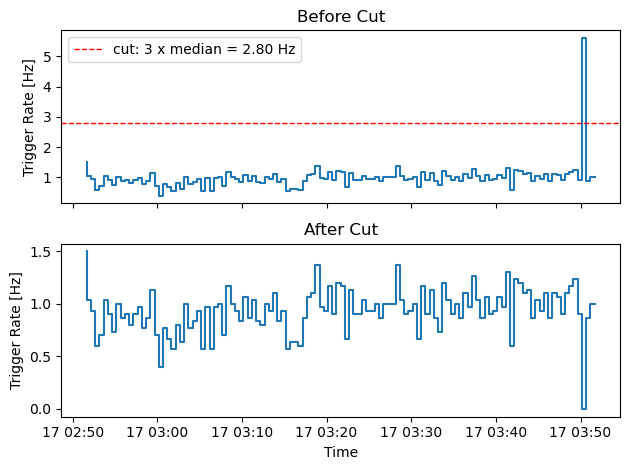

Rate spikes at:  DatetimeIndex(['2026-09-17 03:50:39.969398022-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  168  ( 4.73 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:18Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  3101
Number of Events with package loss:  0  ( 0.0 %)


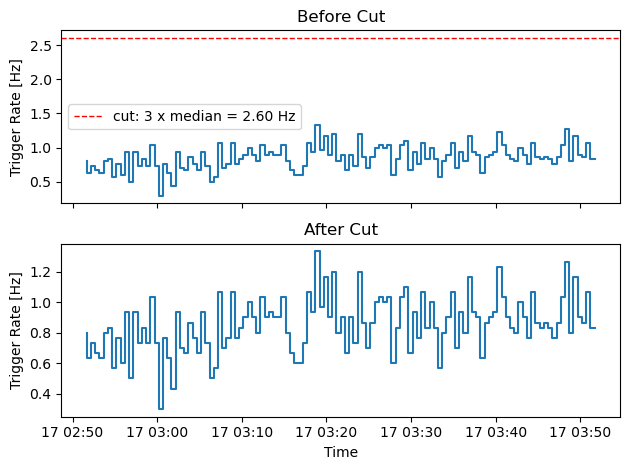

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:17Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  3972
Number of Events with package loss:  0  ( 0.0 %)


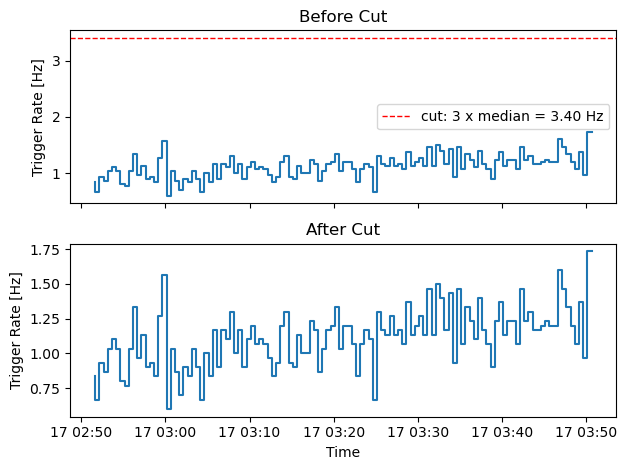

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd/start_2026-09-17T09:51:17Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  3219
Number of Events with package loss:  0  ( 0.0 %)


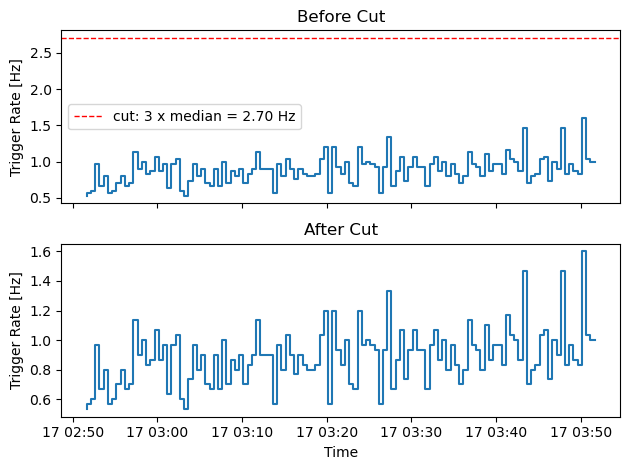

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:55Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  7585
Number of Events with package loss:  4  ( 0.05 %)


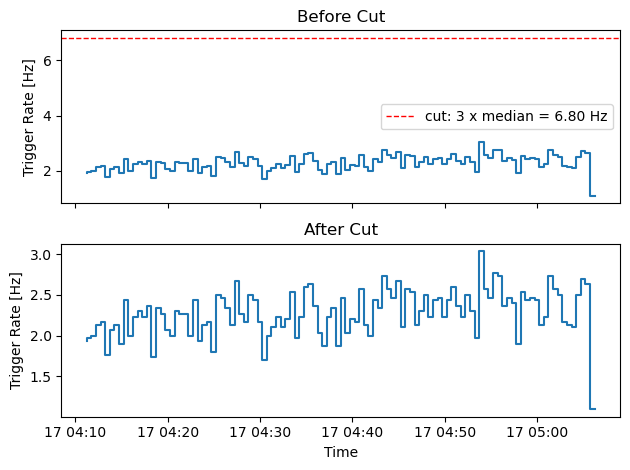

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:55Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  7431
Number of Events with package loss:  4  ( 0.05 %)


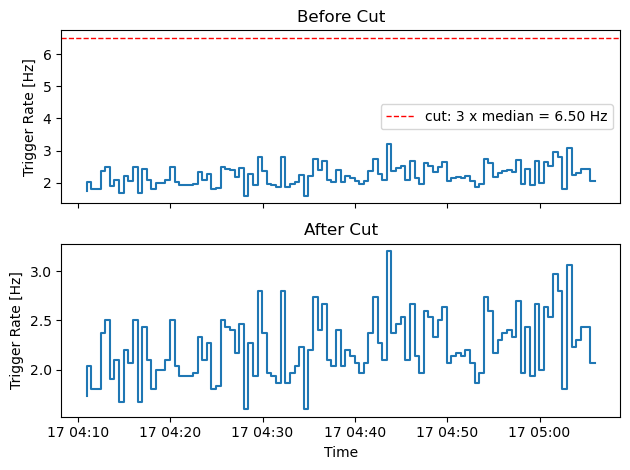

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:54Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  9829
Number of Events with package loss:  4  ( 0.04 %)


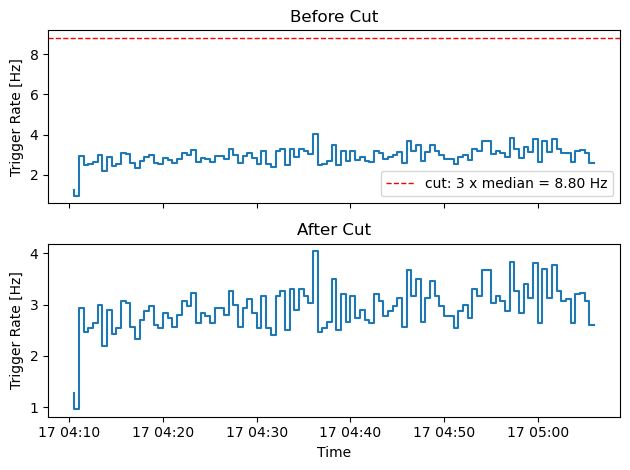

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260917 obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260917/pff/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd/start_2026-09-17T11:09:54Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  7723
Number of Events with package loss:  0  ( 0.0 %)


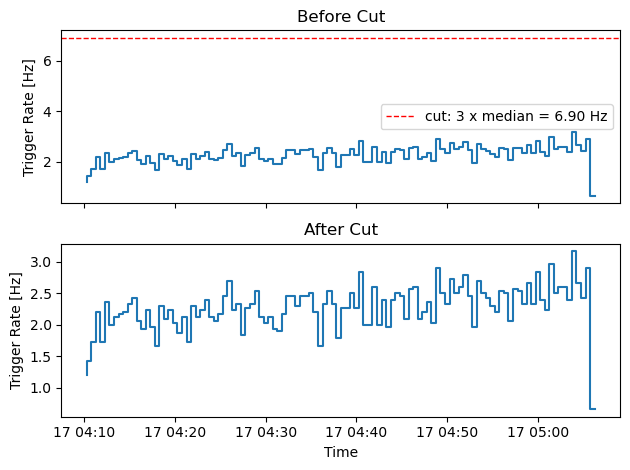

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/start_2026-09-18T05:35:13Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  248093
Number of Events with package loss:  192473  ( 77.58 %)


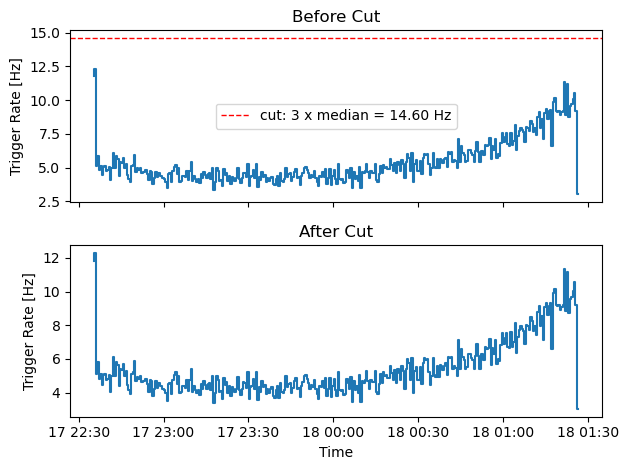

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/start_2026-09-18T05:35:12Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  267785
Number of Events with package loss:  211215  ( 78.87 %)


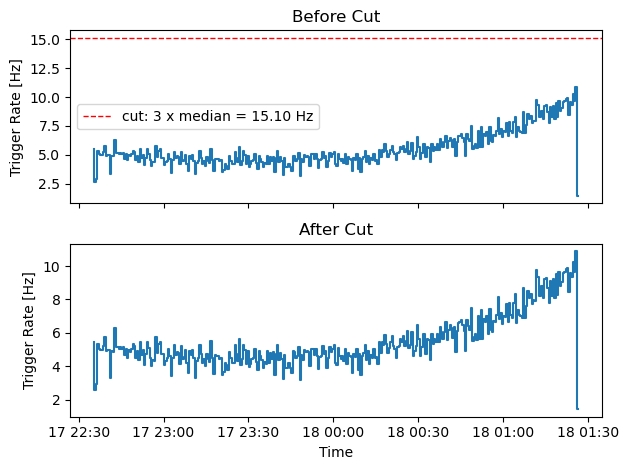

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/start_2026-09-18T05:35:11Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  102562
Number of Events with package loss:  11  ( 0.01 %)


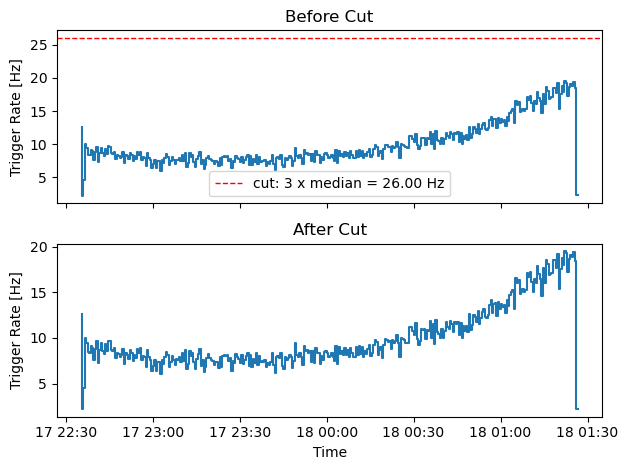

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260918 obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/obs_Palomar.start_2026-09-18T05:34:13Z.runtype_eng-interleave.pffd/start_2026-09-18T05:35:12Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  69525
Number of Events with package loss:  5  ( 0.01 %)


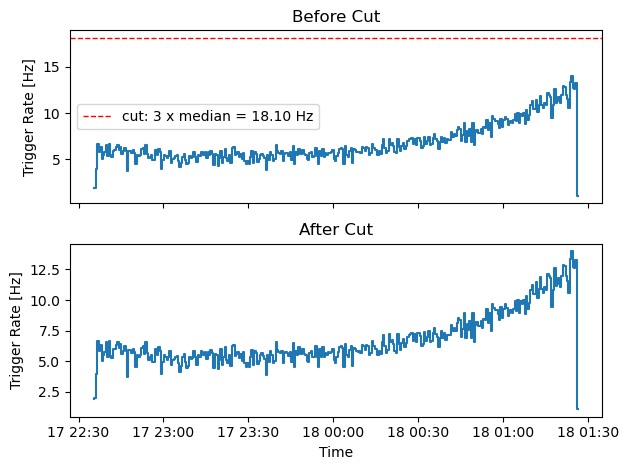

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260918 obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/start_2026-09-18T10:54:15Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  12730
Number of Events with package loss:  9  ( 0.07 %)


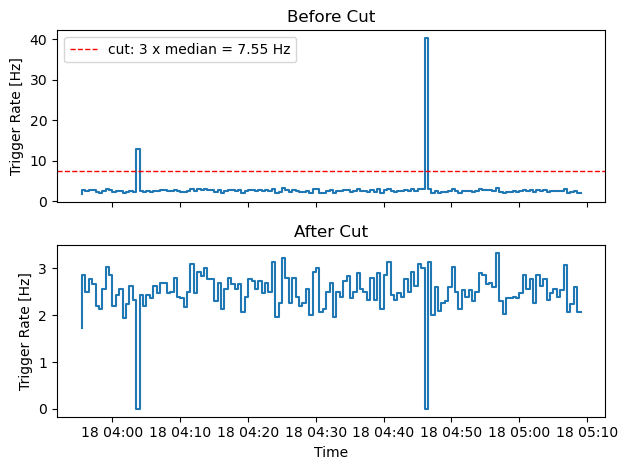

Rate spikes at:  DatetimeIndex(['2026-09-18 04:04:01.744538069-07:00', '2026-09-18 04:46:31.744538069-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  1593  ( 12.52 %)
20260918 obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/start_2026-09-18T10:54:15Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  11654
Number of Events with package loss:  4  ( 0.03 %)


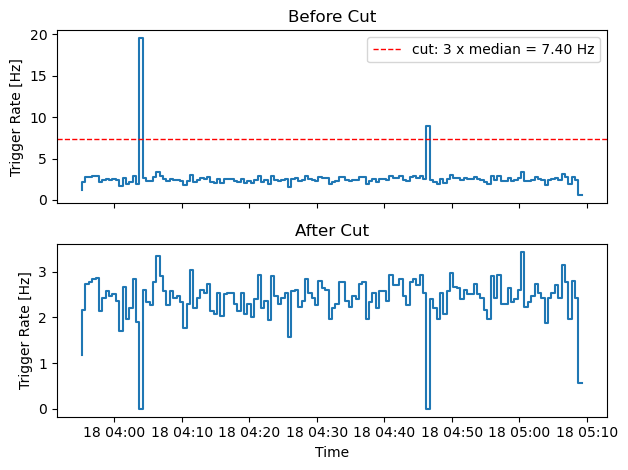

Rate spikes at:  DatetimeIndex(['2026-09-18 04:04:14.332139969-07:00', '2026-09-18 04:46:44.332139969-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  854  ( 7.33 %)
20260918 obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/start_2026-09-18T10:54:14Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  16456
Number of Events with package loss:  8  ( 0.05 %)


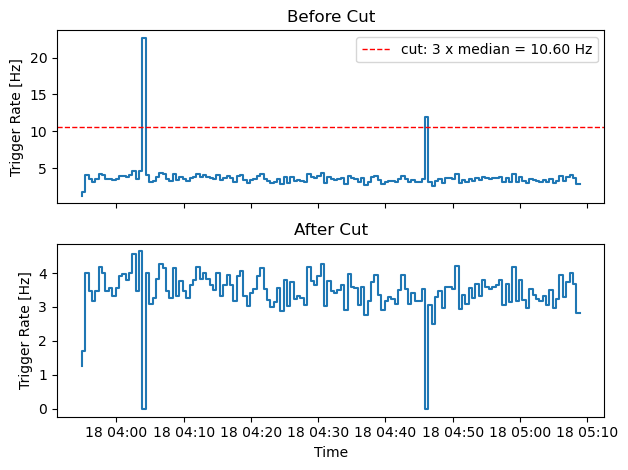

Rate spikes at:  DatetimeIndex(['2026-09-18 04:04:21.851762056-07:00', '2026-09-18 04:46:21.851762056-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  1038  ( 6.31 %)
20260918 obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260918/pff/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd/start_2026-09-18T10:54:15Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  11799
Number of Events with package loss:  0  ( 0.0 %)


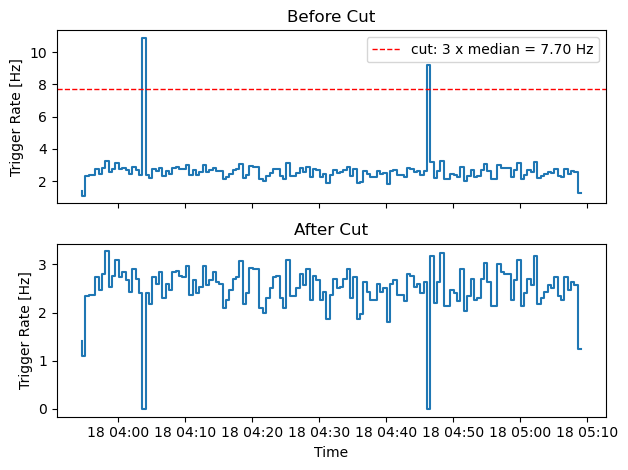

Rate spikes at:  DatetimeIndex(['2026-09-18 04:04:06.168334007-07:00', '2026-09-18 04:46:36.168334007-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  602  ( 5.1 %)
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:28Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  6632
Number of Events with package loss:  4  ( 0.06 %)


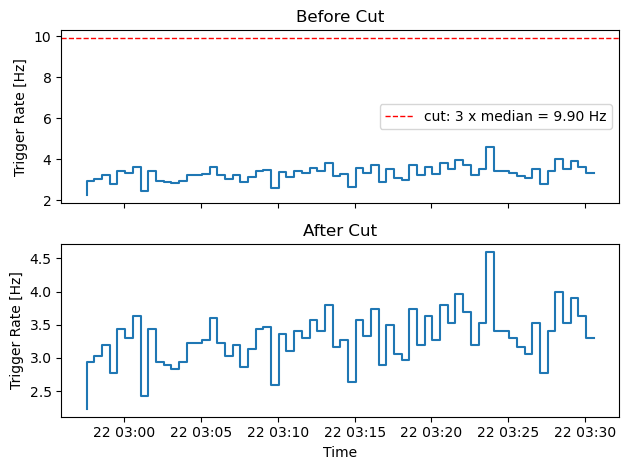

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:28Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  4513
Number of Events with package loss:  4  ( 0.09 %)


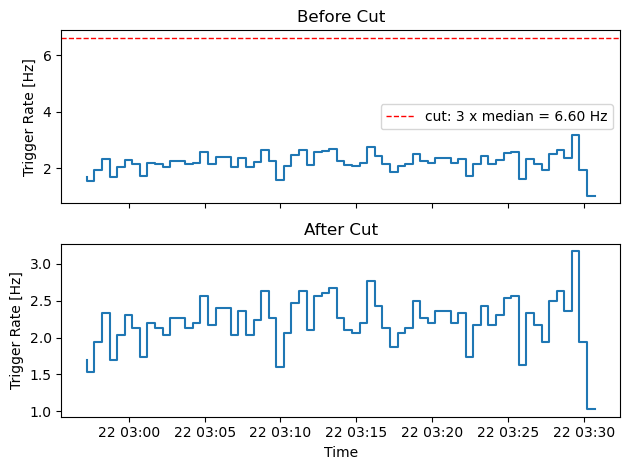

Rate spikes at:  DatetimeIndex([], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:27Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  7514
Number of Events with package loss:  0  ( 0.0 %)


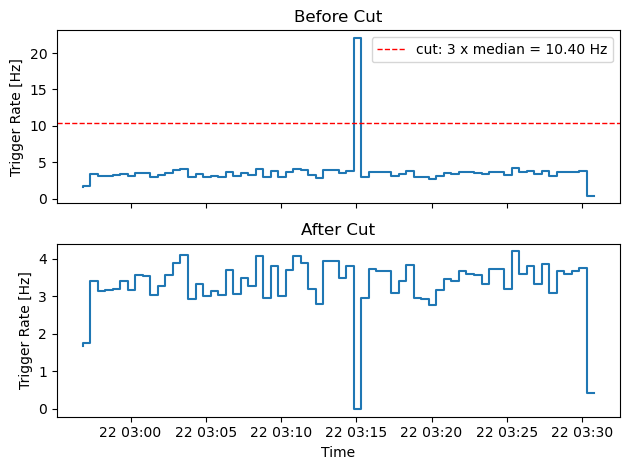

Rate spikes at:  DatetimeIndex(['2026-09-22 03:15:18.897461891-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  661  ( 8.8 %)
20260922 obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:27Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  2358
Number of Events with package loss:  2358  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file
20260922 obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd Heli (rate_cut 3 x median rate)
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/st

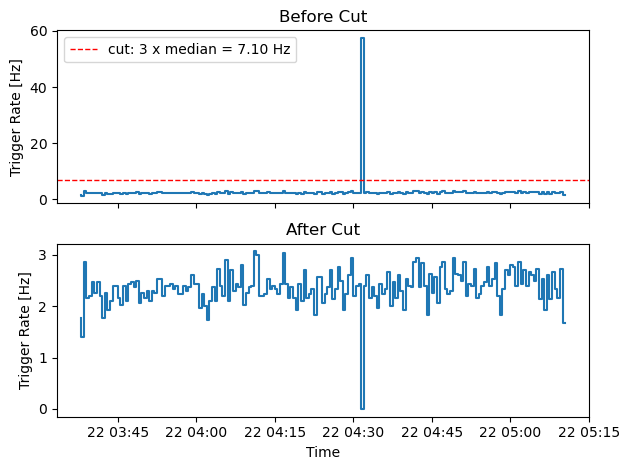

Rate spikes at:  DatetimeIndex(['2026-09-22 04:31:58.508275032-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  1721  ( 11.55 %)
20260922 obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd Fern (rate_cut 3 x median rate)
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/start_2026-09-22T10:37:36Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  14637
Number of Events with package loss:  2  ( 0.01 %)


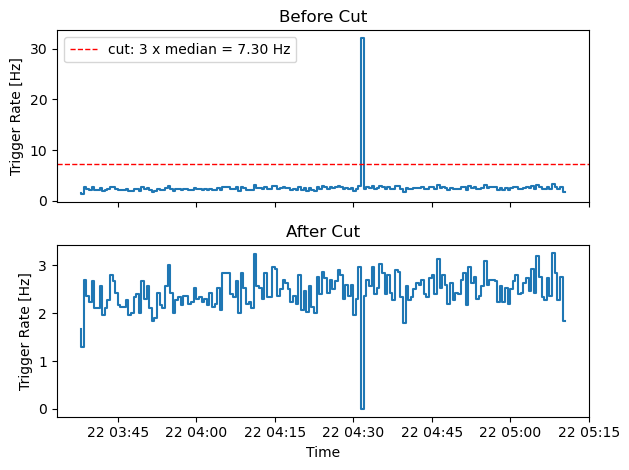

Rate spikes at:  DatetimeIndex(['2026-09-22 04:31:58.057598114-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  962  ( 6.57 %)
20260922 obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd Winter (rate_cut 3 x median rate)
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/start_2026-09-22T10:37:35Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  17869
Number of Events with package loss:  0  ( 0.0 %)


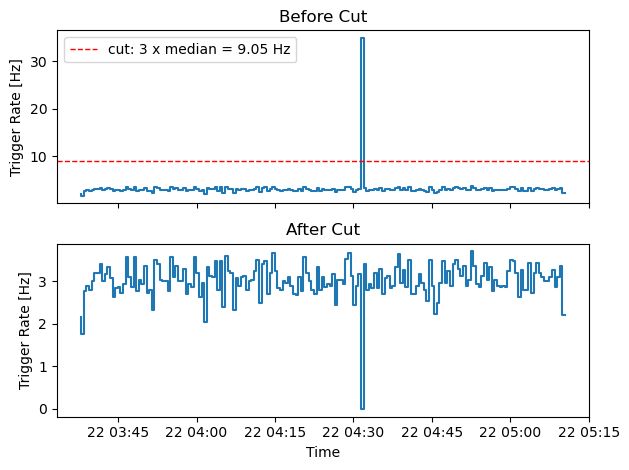

Rate spikes at:  DatetimeIndex(['2026-09-22 04:31:56.437613964-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  1044  ( 5.84 %)
20260922 obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd Gattini (rate_cut 3 x median rate)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/start_2026-09-22T10:37:38Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  3219
Number of Events with package loss:  3219  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file


In [7]:
if RAW_DIAGNOSTICS:
    for date in DATES:
        for run_dir in discover_runs(RAW_DATA_DIR / date):
            for module, info in TELESCOPE_MODULES.items():
                if any(run_dir.glob(f"*{DATA_PRODUCT}*{module}*.pff")):
                    print(f"{date} {run_dir.name} {info['name']} (rate_cut {info['rate_cut']} x median rate)")
                    coinc.load_telescope_tv(f"{DATA_PRODUCT}*{module}", run_dir, info["rate_cut"], plotting=True)

## Timing and coincidences
Each telescope's timing offset to its timing reference (in each 120 s of each run, the first telescope in `REFERENCE` with data) before and after correction, then events per telescope combination
(images matched within `COINC_WINDOW`, before any cuts; see `heap.events.build_events()`).

20260917
obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd, 09:51:23-10:51:23 UTC: timing reference Winter; Heli 3357, Fern 3076, Winter 3972, Gattini 3189 images
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  6e-05 s, std= 5e-05 s
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


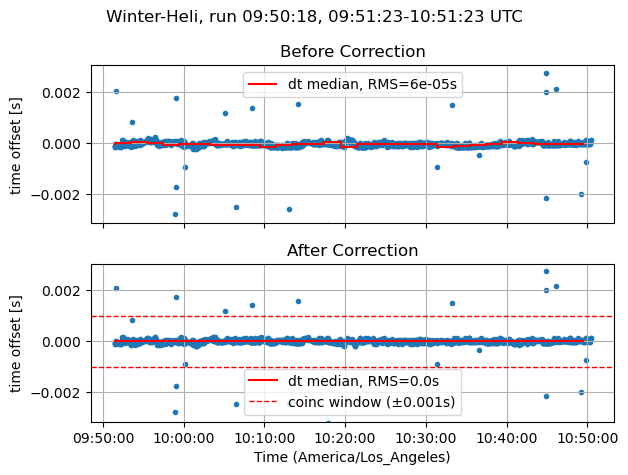

Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  7e-05 s, std= 5e-05 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


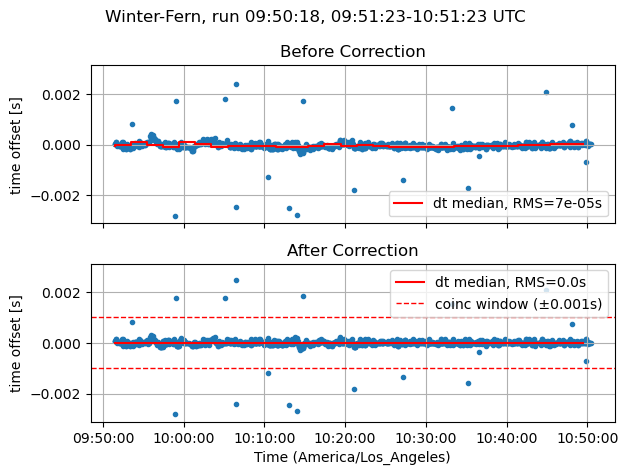

Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  0.00036 s, std= 0.00035 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


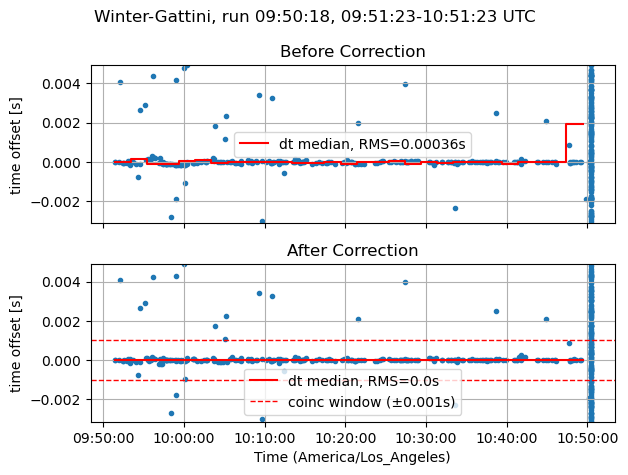

Heli-Fern within 0.001s: 1612/3353 Heli events (48.1%) and 1612/3076 Fern events (52.4%) coincident, 1614 pairs
Heli-Winter within 0.001s: 1481/3353 Heli events (44.2%) and 1483/3972 Winter events (37.3%) coincident, 1484 pairs
Heli-Gattini within 0.001s: 216/3353 Heli events (6.4%) and 216/3188 Gattini events (6.8%) coincident, 216 pairs
Fern-Winter within 0.001s: 1252/3076 Fern events (40.7%) and 1253/3972 Winter events (31.5%) coincident, 1254 pairs
Fern-Gattini within 0.001s: 120/3076 Fern events (3.9%) and 120/3188 Gattini events (3.8%) coincident, 120 pairs
Winter-Gattini within 0.001s: 264/3972 Winter events (6.6%) and 242/3188 Gattini events (7.6%) coincident, 279 pairs
2368 events; dropped 7 ambiguous groups (a telescope matched more than one image)

obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd, 10:51:23-10:53:23 UTC: timing reference Fern (no Winter images); Heli 30, Fern 25, Gattini 30 images
Fern-Heli, run 09:50:18, 10:51:23-10:53:23 UTC timing offset: RMS= 

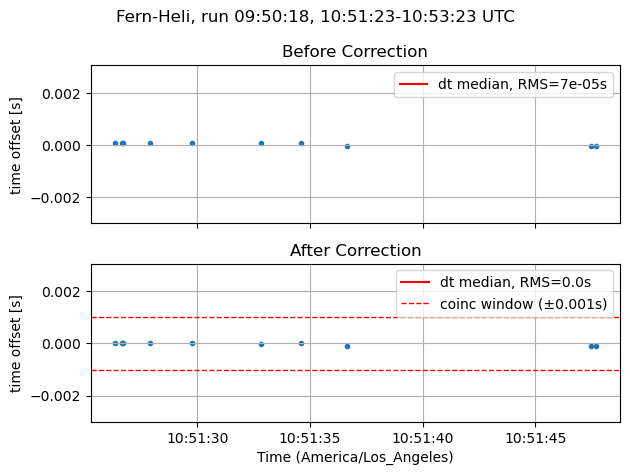

Gattini: no coincidences with Fern in this stretch, not matched into events here
Heli-Fern within 0.001s: 10/30 Heli events (33.3%) and 10/25 Fern events (40.0%) coincident, 10 pairs
10 events; dropped 0 ambiguous groups (a telescope matched more than one image)

obs_Palomar.start_2026-09-17T11:08:55Z.runtype_eng-phonly.pffd, 11:10:00-12:08:00 UTC: timing reference Winter; Heli 7581, Fern 7427, Winter 9825, Gattini 7723 images
Winter-Heli, run 11:08:55, 11:10:00-12:08:00 UTC timing offset: RMS=  0.00011 s, std= 7e-05 s
Winter-Heli, run 11:08:55, 11:10:00-12:08:00 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


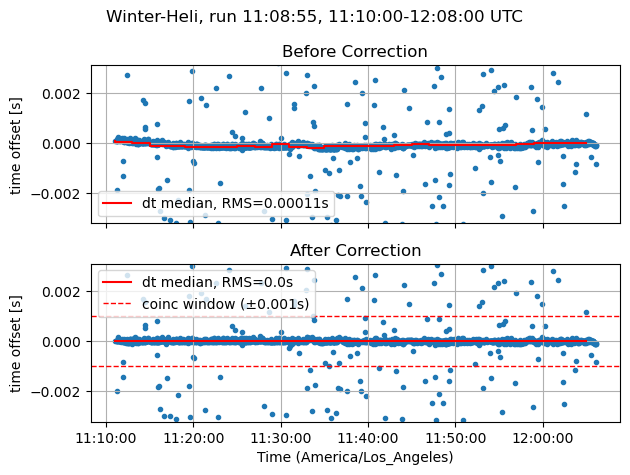

Winter-Fern, run 11:08:55, 11:10:00-12:08:00 UTC timing offset: RMS=  0.0001 s, std= 5e-05 s
Winter-Fern, run 11:08:55, 11:10:00-12:08:00 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


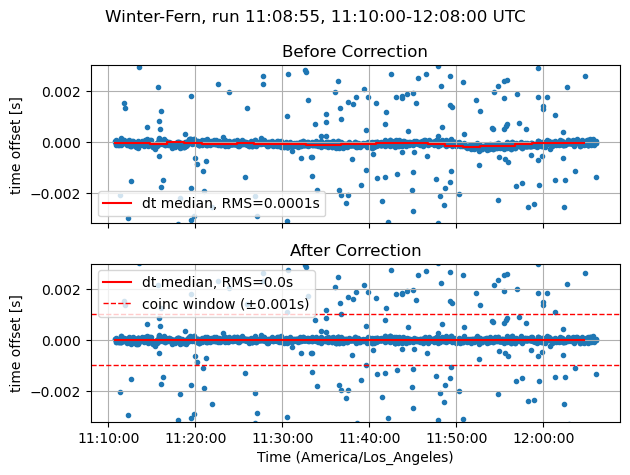

Winter-Gattini, run 11:08:55, 11:10:00-12:08:00 UTC timing offset: RMS=  0.00105 s, std= 0.00105 s
Winter-Gattini, run 11:08:55, 11:10:00-12:08:00 UTC corrected offset: RMS=  0.00089 s, std= 0.00089 s


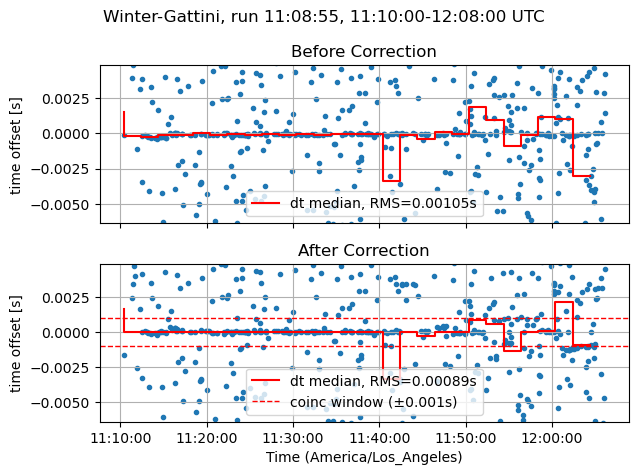

Heli-Fern within 0.001s: 2723/7581 Heli events (35.9%) and 2719/7425 Fern events (36.6%) coincident, 2742 pairs
Heli-Winter within 0.001s: 1944/7581 Heli events (25.6%) and 1945/9825 Winter events (19.8%) coincident, 1960 pairs
Heli-Gattini within 0.001s: 207/7581 Heli events (2.7%) and 206/7695 Gattini events (2.7%) coincident, 208 pairs
Fern-Winter within 0.001s: 1892/7425 Fern events (25.5%) and 1891/9825 Winter events (19.2%) coincident, 1905 pairs
Fern-Gattini within 0.001s: 119/7425 Fern events (1.6%) and 119/7695 Gattini events (1.5%) coincident, 120 pairs
Winter-Gattini within 0.001s: 209/9825 Winter events (2.1%) and 210/7695 Gattini events (2.7%) coincident, 210 pairs
3910 events; dropped 47 ambiguous groups (a telescope matched more than one image)

20260918
obs_Palomar.start_2026-09-18T10:53:14Z.runtype_ph.pffd, 10:54:21-12:10:21 UTC: timing reference Winter; Heli 11128, Fern 10796, Winter 15410, Gattini 11197 images
Winter-Heli, run 10:53:14, 10:54:21-12:10:21 UTC timing o

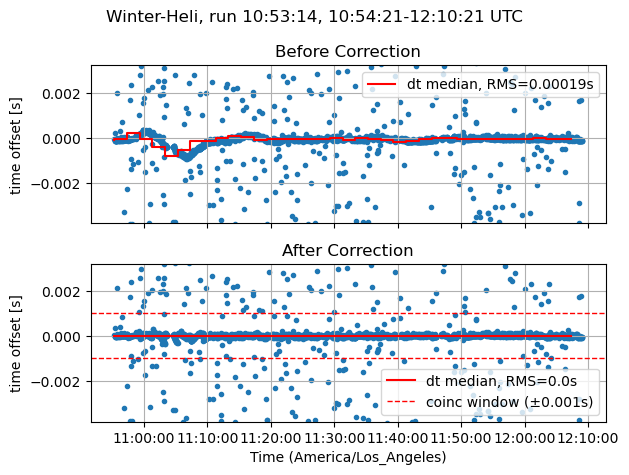

Winter-Fern, run 10:53:14, 10:54:21-12:10:21 UTC timing offset: RMS=  0.00013 s, std= 0.00011 s
Winter-Fern, run 10:53:14, 10:54:21-12:10:21 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


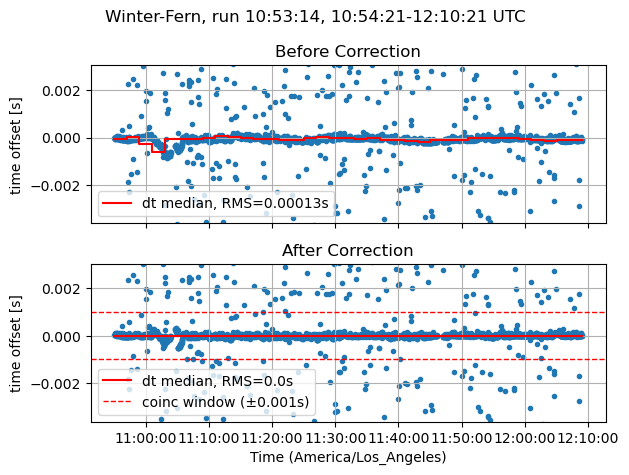

Winter-Gattini, run 10:53:14, 10:54:21-12:10:21 UTC timing offset: RMS=  0.00168 s, std= 0.00167 s
Winter-Gattini, run 10:53:14, 10:54:21-12:10:21 UTC corrected offset: RMS=  0.00088 s, std= 0.00088 s


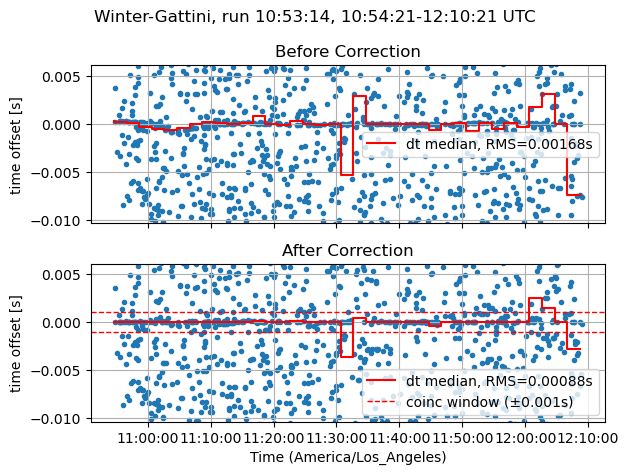

Heli-Fern within 0.001s: 3679/11125 Heli events (33.1%) and 3679/10793 Fern events (34.1%) coincident, 3697 pairs
Heli-Winter within 0.001s: 2559/11125 Heli events (23.0%) and 2571/15410 Winter events (16.7%) coincident, 2579 pairs
Heli-Gattini within 0.001s: 315/11125 Heli events (2.8%) and 315/11173 Gattini events (2.8%) coincident, 317 pairs
Fern-Winter within 0.001s: 2492/10793 Fern events (23.1%) and 2506/15410 Winter events (16.3%) coincident, 2514 pairs
Fern-Gattini within 0.001s: 162/10793 Fern events (1.5%) and 164/11173 Gattini events (1.5%) coincident, 164 pairs
Winter-Gattini within 0.001s: 312/15410 Winter events (2.0%) and 310/11173 Gattini events (2.8%) coincident, 313 pairs
5380 events; dropped 55 ambiguous groups (a telescope matched more than one image)

20260922
obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd, 10:37:41-12:11:41 UTC: timing reference Winter; Heli 13173, Fern 13673, Winter 16825 images
Winter-Heli, run 10:36:38, 10:37:41-12:11:41 UTC timing offs

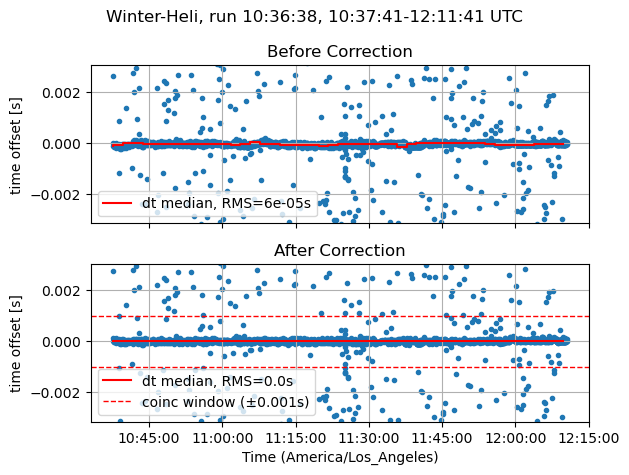

Winter-Fern, run 10:36:38, 10:37:41-12:11:41 UTC timing offset: RMS=  9e-05 s, std= 7e-05 s
Winter-Fern, run 10:36:38, 10:37:41-12:11:41 UTC corrected offset: RMS=  0.0 s, std= 0.0 s


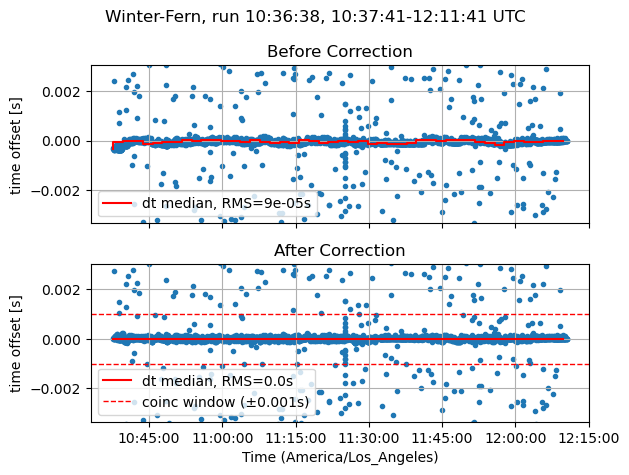

Heli-Fern within 0.001s: 4704/13173 Heli events (35.7%) and 4702/13673 Fern events (34.4%) coincident, 4755 pairs
Heli-Winter within 0.001s: 3172/13173 Heli events (24.1%) and 3175/16825 Winter events (18.9%) coincident, 3195 pairs
Fern-Winter within 0.001s: 3223/13673 Fern events (23.6%) and 3227/16825 Winter events (19.2%) coincident, 3249 pairs
6409 events; dropped 57 ambiguous groups (a telescope matched more than one image)



,20260917,20260918,20260922
Telescope,,,
Fern + Gattini,22,30,0
Fern + Gattini + Heli,18,20,0
Fern + Gattini + Heli + Winter,191,101,0
Fern + Gattini + Winter,4,7,0
Fern + Heli,1900,1863,2376
Fern + Heli + Winter,2181,1634,2257
Fern + Winter,720,713,913
Gattini + Heli,107,107,0
Gattini + Heli + Winter,103,79,0


In [8]:
combos = {}
for date in DATES:
    print(date)
    events, _ = ev.build_array_events(OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW,
                                      wobble_offset=WOBBLE_OFFSET, pointing_overrides=POINTING_OVERRIDES, plotting=True)
    if events is not None and len(events):
        combos[date] = events.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()
pd.DataFrame(combos).fillna(0).astype(int)

## Processed data
Every telescope and source written, per night. Frames (images) are after the packet-loss and spike cuts; Cleaned is the
fraction with any pixel left after cleaning. A row with no Source is a telescope with no usable frames that night.

In [9]:
products = dg.product_table(OUTPUT_DIR, DATES)
products.drop(columns="Settings")

,Date,Telescope,Source,Frames,Start,End,Hours,Rate,Cleaned,GainSource,MB
0,20260917,Fern,Crab,10528,2026-09-17 09:51:26+00:00,2026-09-17 12:06:08+00:00,2.25,1.30,0.863,other_night:20260918,130.6
1,20260917,Gattini,Crab,10942,2026-09-17 09:51:24+00:00,2026-09-17 12:06:07+00:00,2.25,1.35,0.764,other_night:20260918,135.8
2,20260917,Heli,Crab,10968,2026-09-17 09:51:24+00:00,2026-09-17 12:06:10+00:00,2.25,1.36,0.880,other_night:20260918,136.1
3,20260917,Winter,Crab,13797,2026-09-17 09:51:23+00:00,2026-09-17 12:06:05+00:00,2.25,1.71,0.751,other_night:20260918,171.2
4,20260918,Fern,Crab,10796,2026-09-18 10:54:59+00:00,2026-09-18 12:09:08+00:00,1.24,2.43,0.764,alt,134.0
5,20260918,Fern,MGRO_J2019_37,56570,2026-09-18 05:35:20+00:00,2026-09-18 08:26:25+00:00,2.85,5.51,0.344,alt,701.9
6,20260918,Gattini,Crab,11197,2026-09-18 10:54:21+00:00,2026-09-18 12:09:06+00:00,1.25,2.50,0.649,alt,138.9
7,20260918,Gattini,MGRO_J2019_37,69520,2026-09-18 05:35:21+00:00,2026-09-18 08:26:23+00:00,2.85,6.77,0.266,alt,862.6
8,20260918,Heli,Crab,11128,2026-09-18 10:55:16+00:00,2026-09-18 12:09:09+00:00,1.23,2.51,0.783,alt,138.1
9,20260918,Heli,MGRO_J2019_37,55620,2026-09-18 05:35:19+00:00,2026-09-18 08:26:27+00:00,2.85,5.42,0.371,alt,690.1


## Gain maps
A gain map is each pixel's gain relative to the camera average (mean 1), made once per telescope, source and night;
cleaned images are divided by it. It comes from the pedvar (pedestal variance) of two different star fields: a star
inflates the pedvar of the pixels it falls on, so where the two fields' pedvars differ by more than 3 sigma the lower
one is used, otherwise their average (see `heap.make_gain_map.gain_from_pedvars()`).

The second star field is the first of these that exists, and each map below is titled with which one was used:

| Title | Second star field | |
|---|---|---|
| `own` | the same source on the other side of the meridian flip, same night | the camera is rotated 180 deg, so stars land on different pixels |
| `alt` | the run of another source that night closest in time, either flip side | when the source was only observed on one side of the flip |
| `other_night:<date>` | none; reuses the telescope's gain map from the closest other night in `OUTPUT_DIR`, earlier or later (the earlier on a tie), that was made from that night's own data (`own` or `alt`) | when no other source was observed that night |
| `flat` | none; every pixel is 1, i.e. no gain correction | e.g. the only night processed for this telescope |

`alt` and `other_night` depend on which other runs and nights are in the data, so processing a subset of it can change
the gain maps. A later night is only found if it was processed first, so a night that came out `flat` (or reused a farther
night's map) can pick up a closer one by reprocessing it (`REPROCESS`) after the later nights are processed. `alt` maps are titled with the other source and its flip side; the calibration plots below give each
map's full caption (see `heap.process_dataset.resolve_gain_map()`).

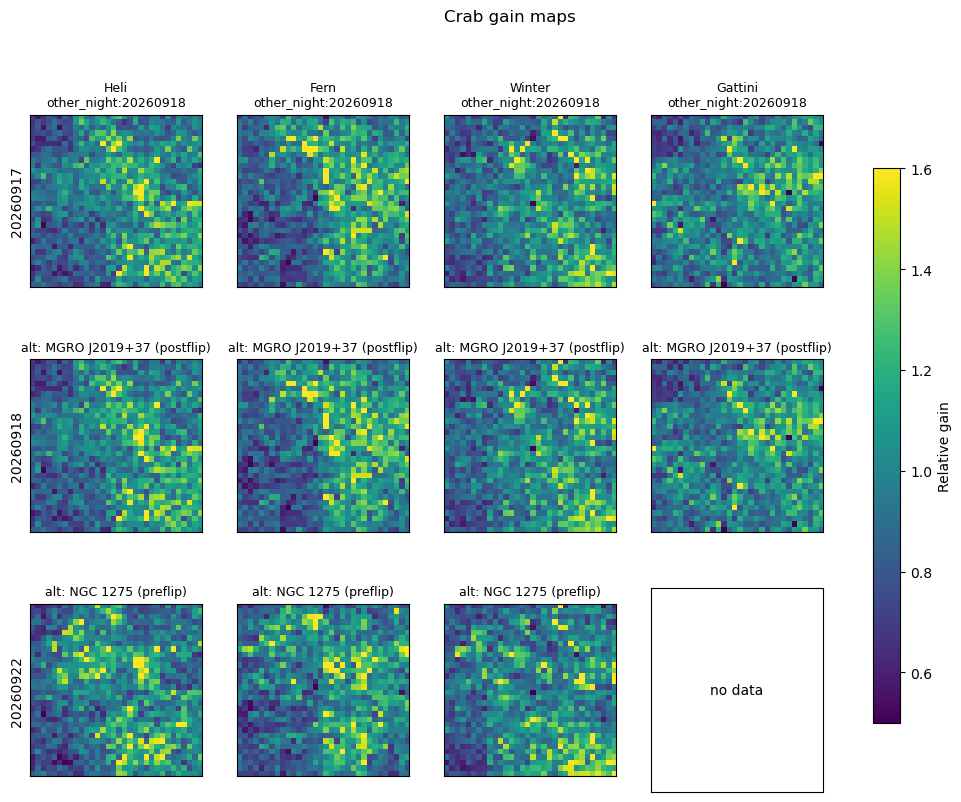

In [10]:
dg.plot_gain_maps(OUTPUT_DIR, DATES, TELESCOPES, SOURCE)
plt.show()

## Calibrations
Per telescope and night: the camera's pedestal and pedvar over time, then the pedestal and pedvar maps applied in each
window they were recomputed in (every 600 s, see `heap.process_dataset.build_calibrations()`), each on one color
scale across the night so changes stand out (e.g. a star raising the pedvar of the pixels it's on).

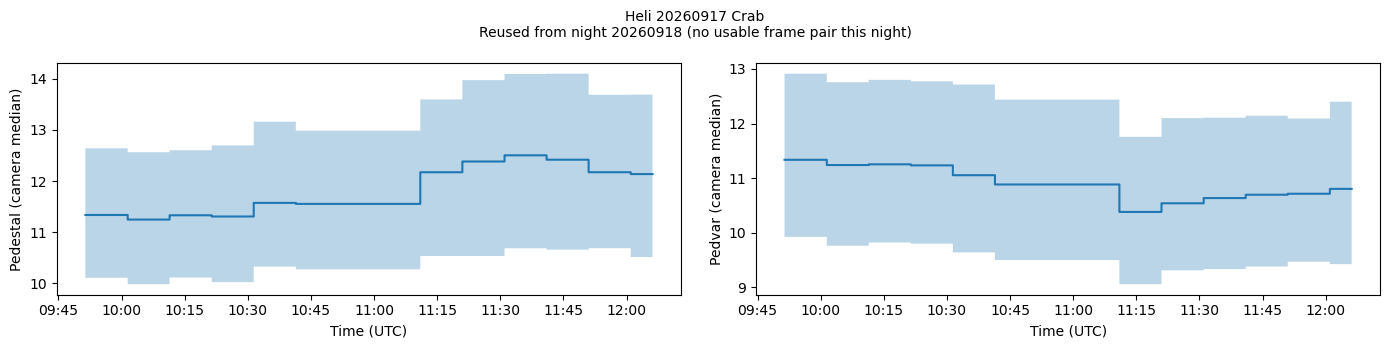

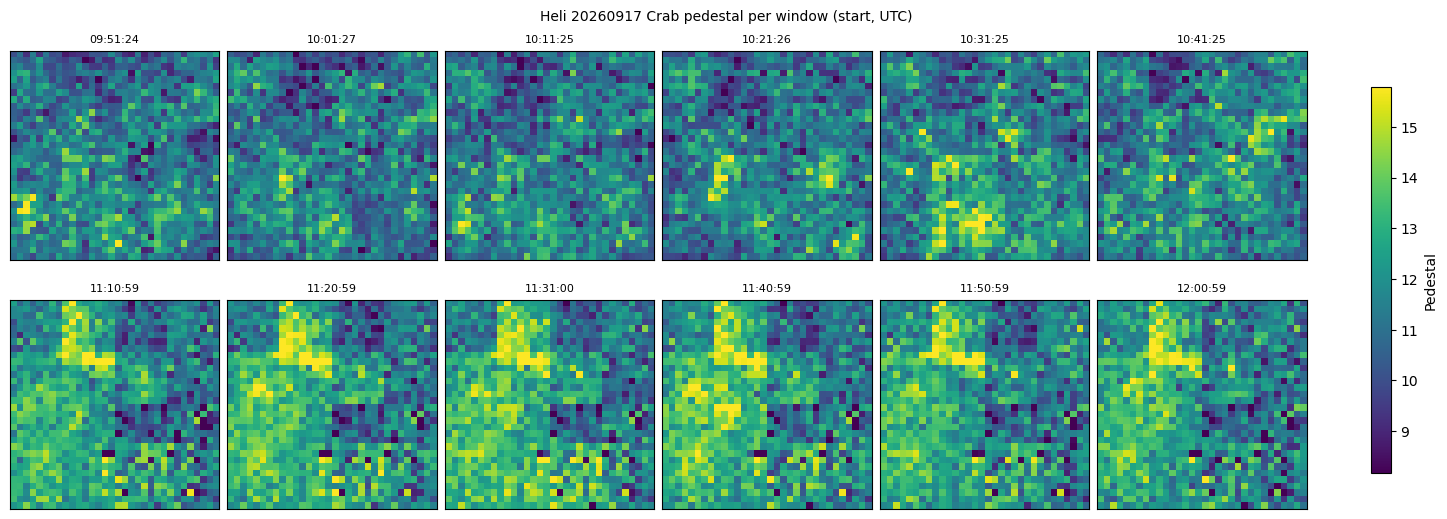

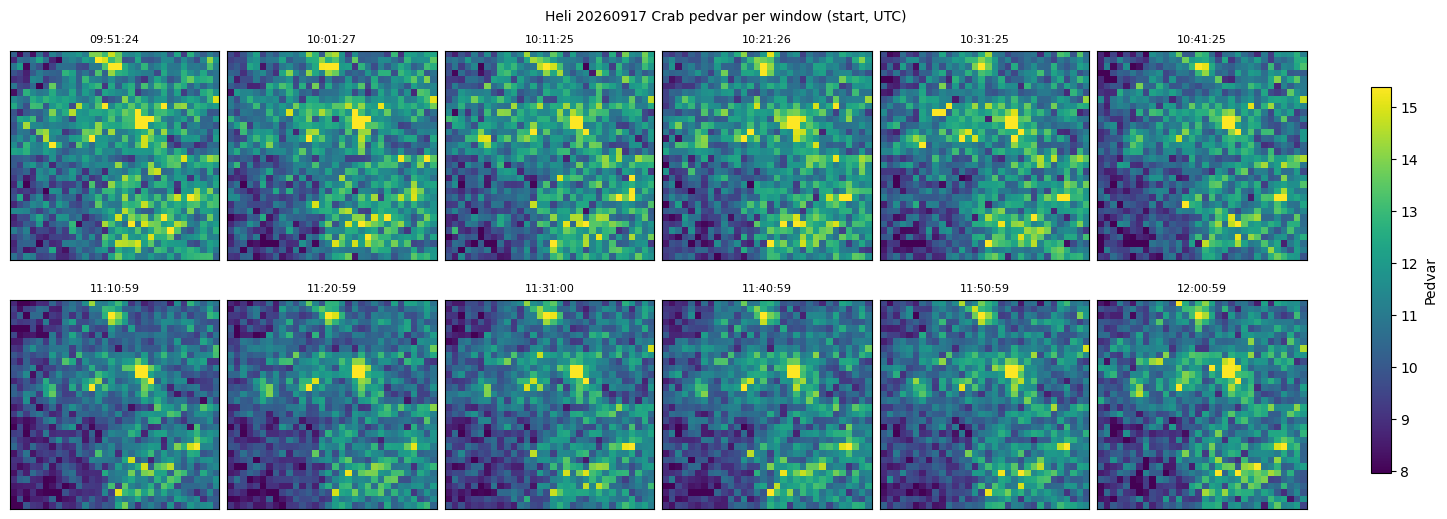

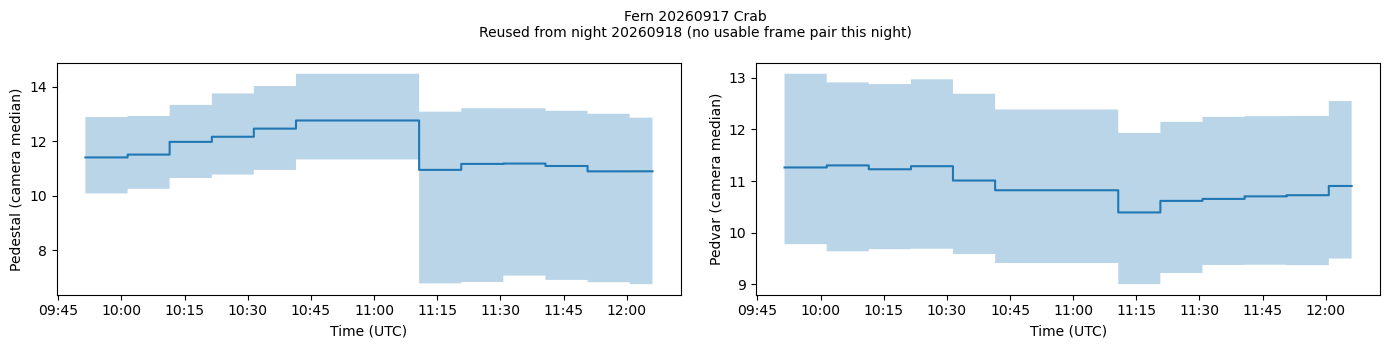

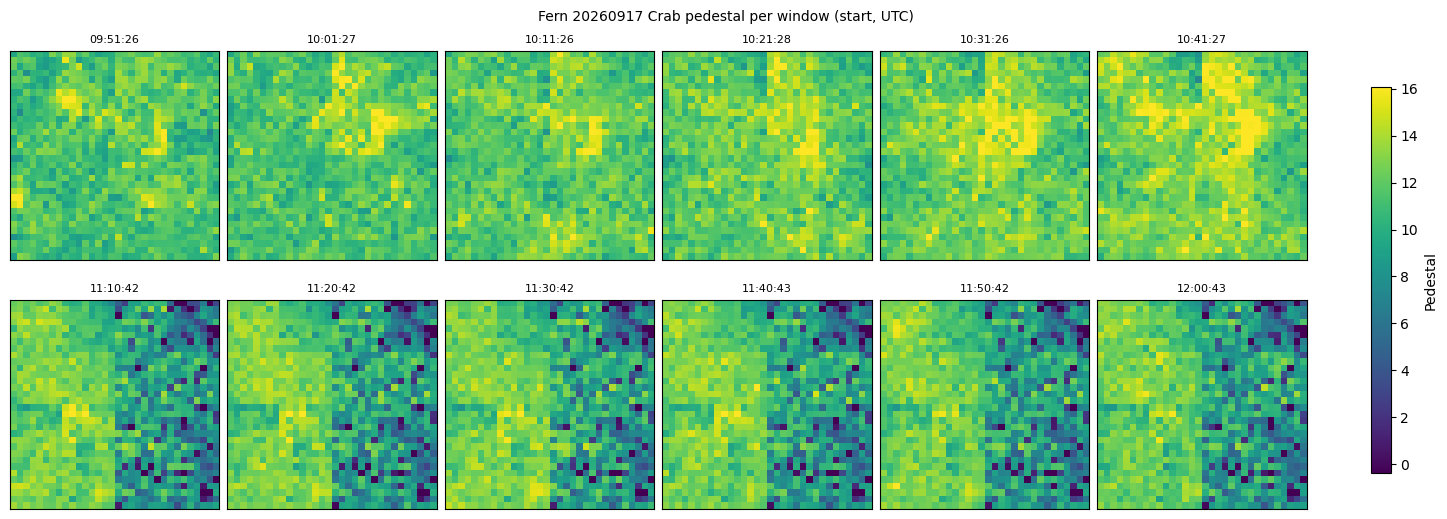

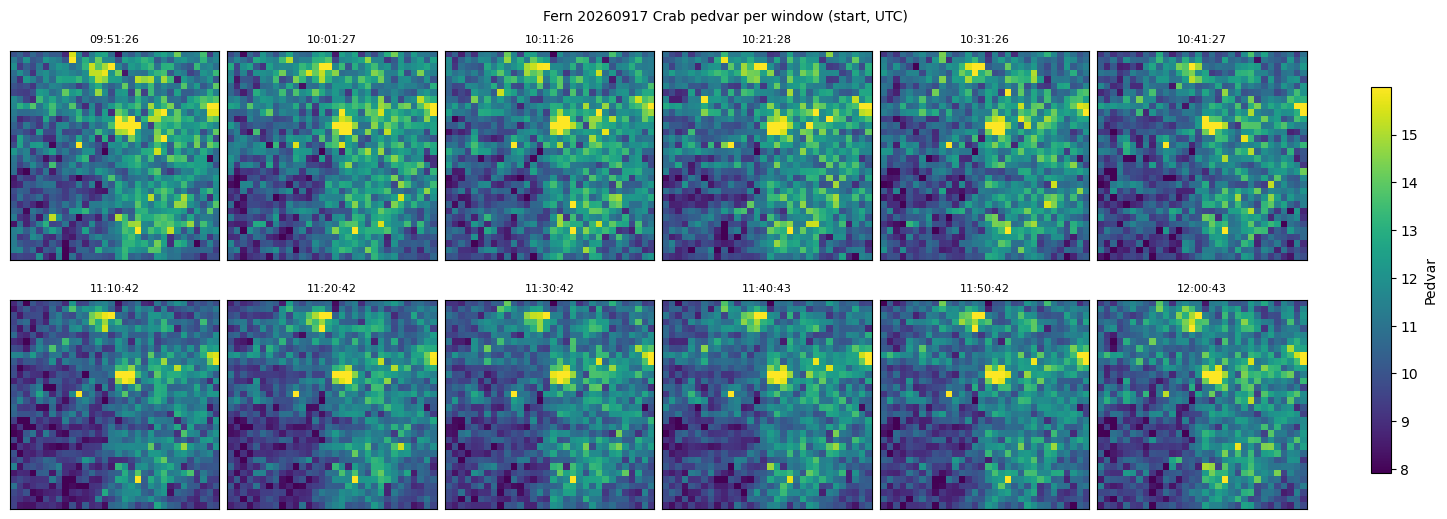

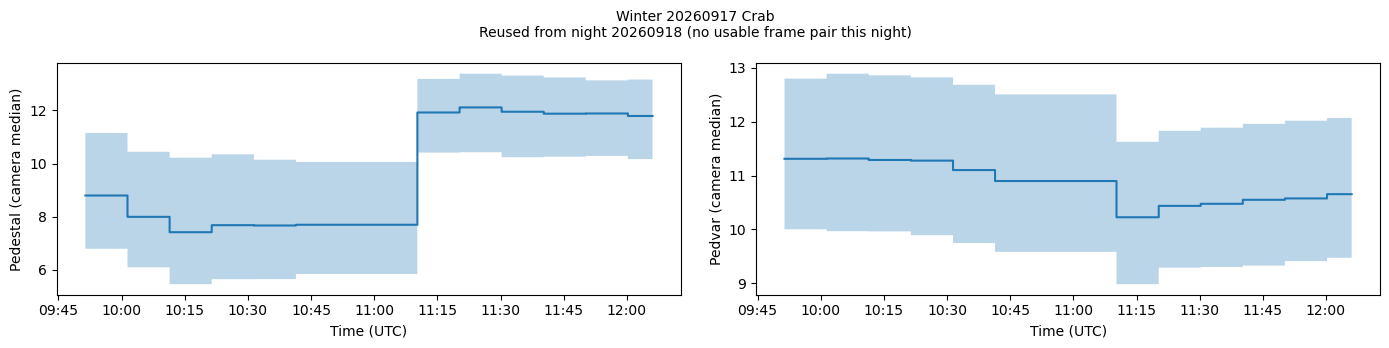

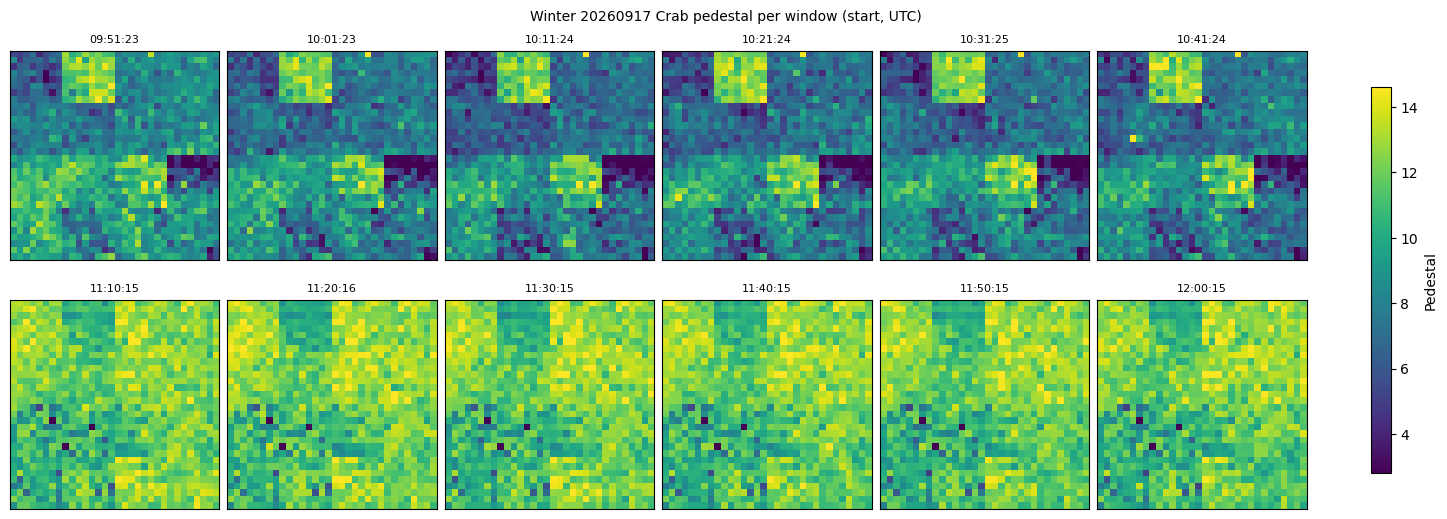

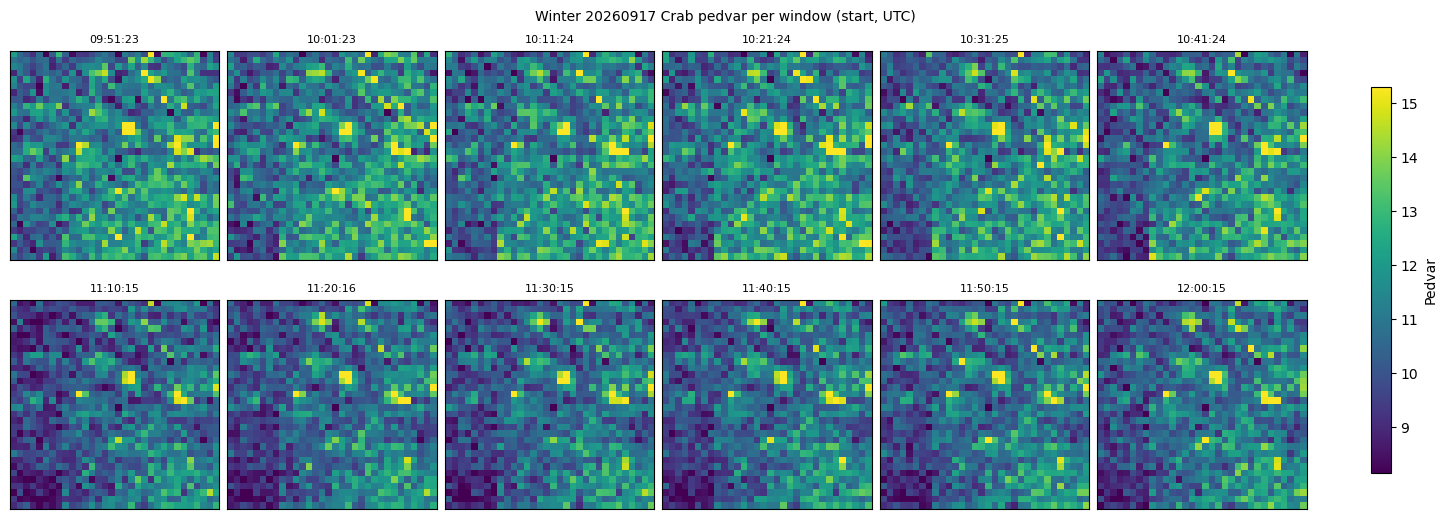

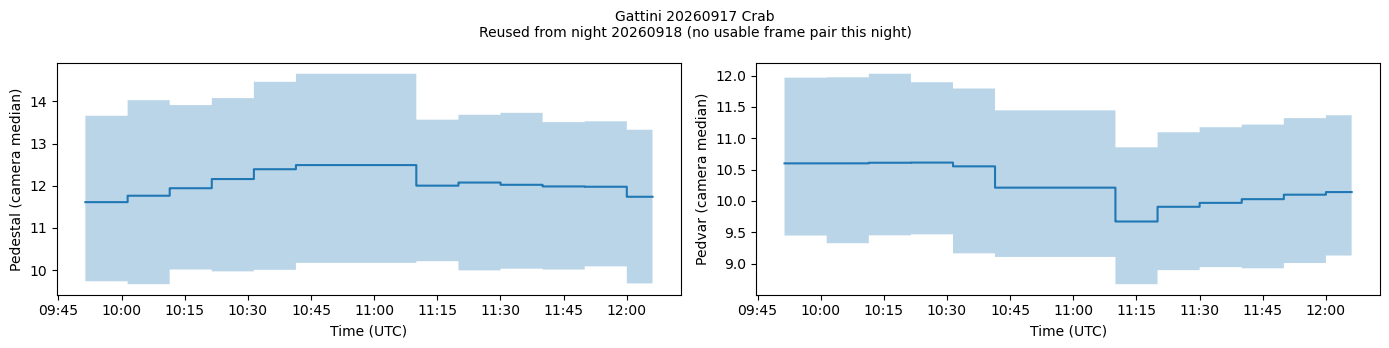

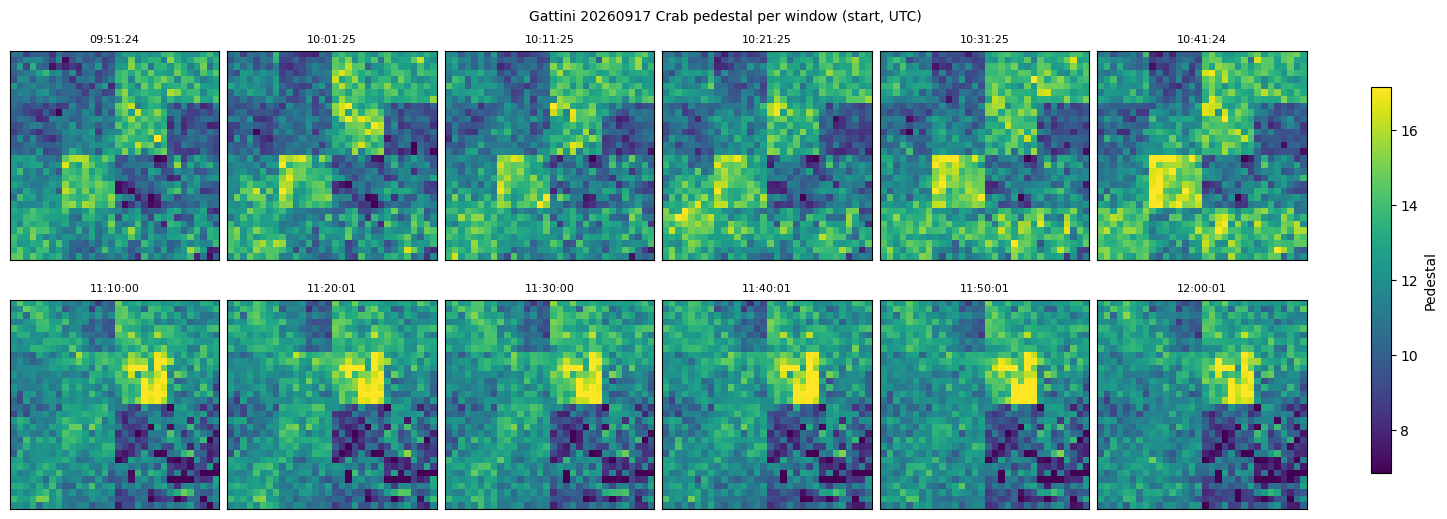

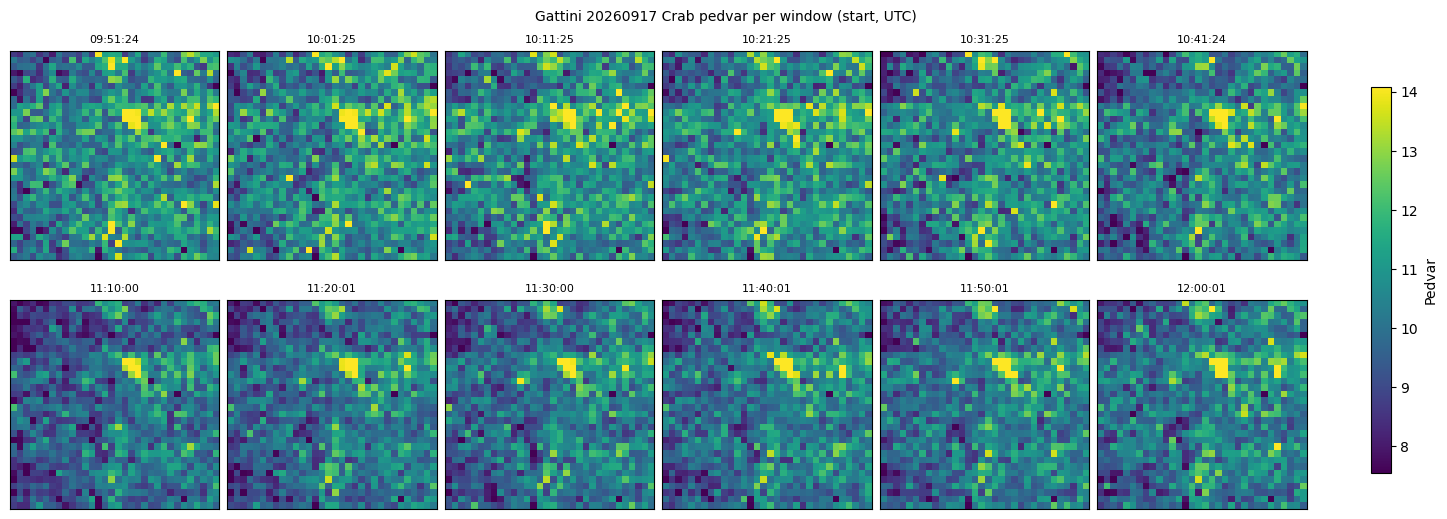

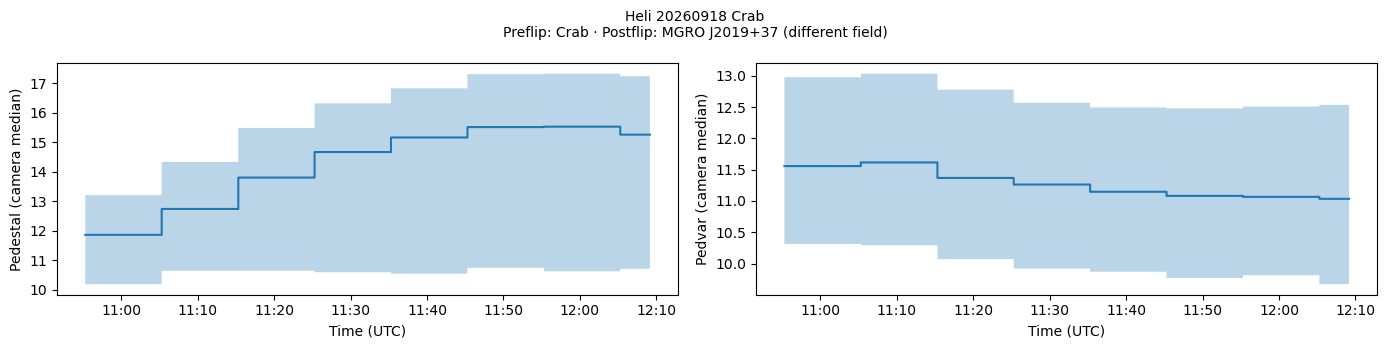

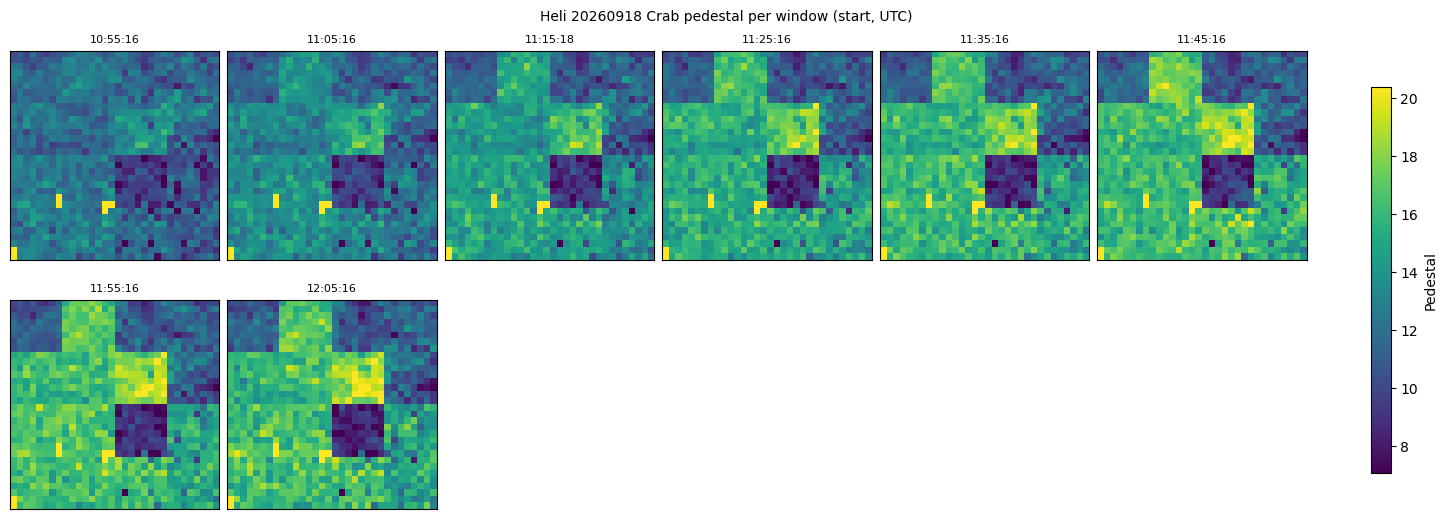

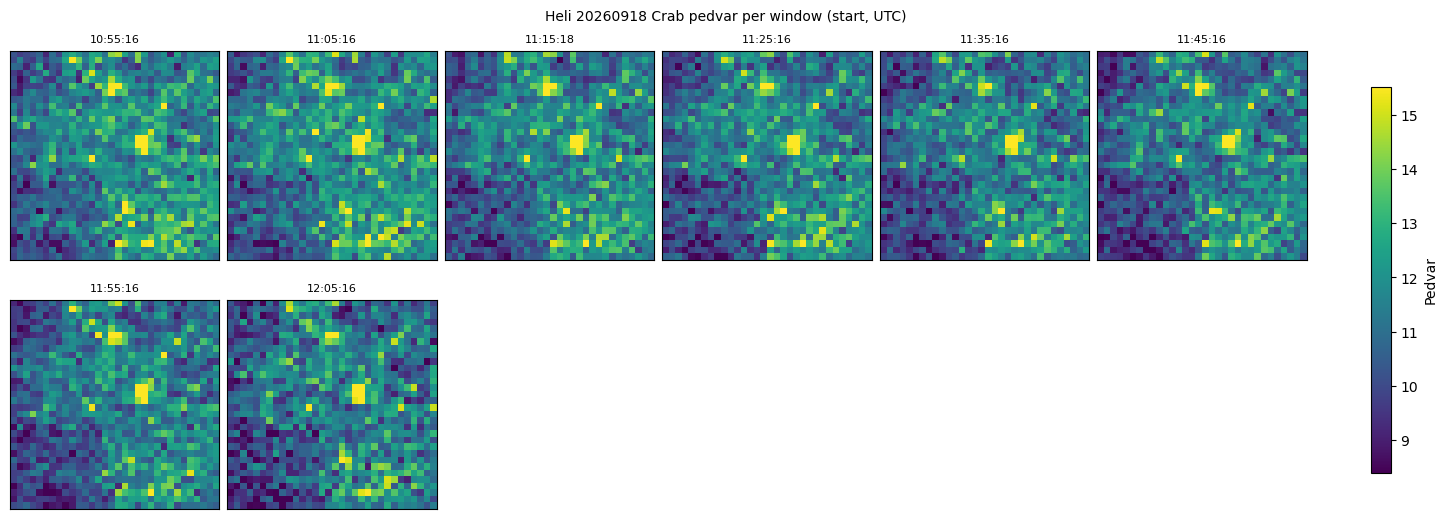

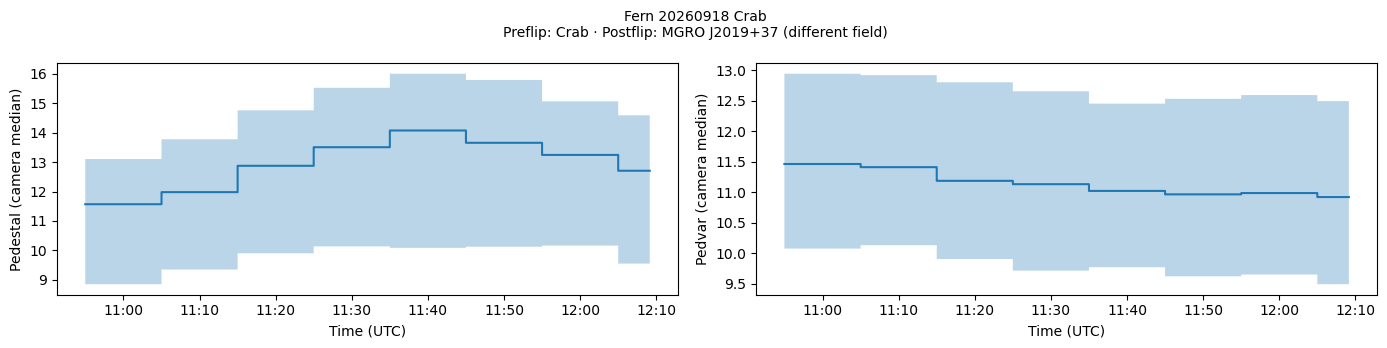

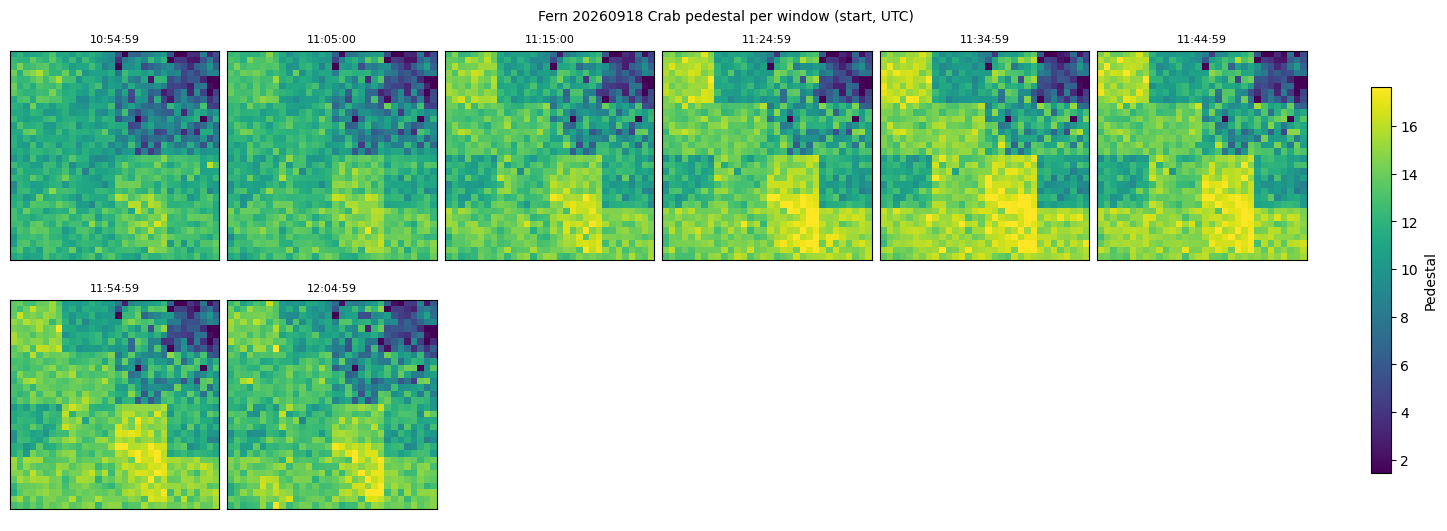

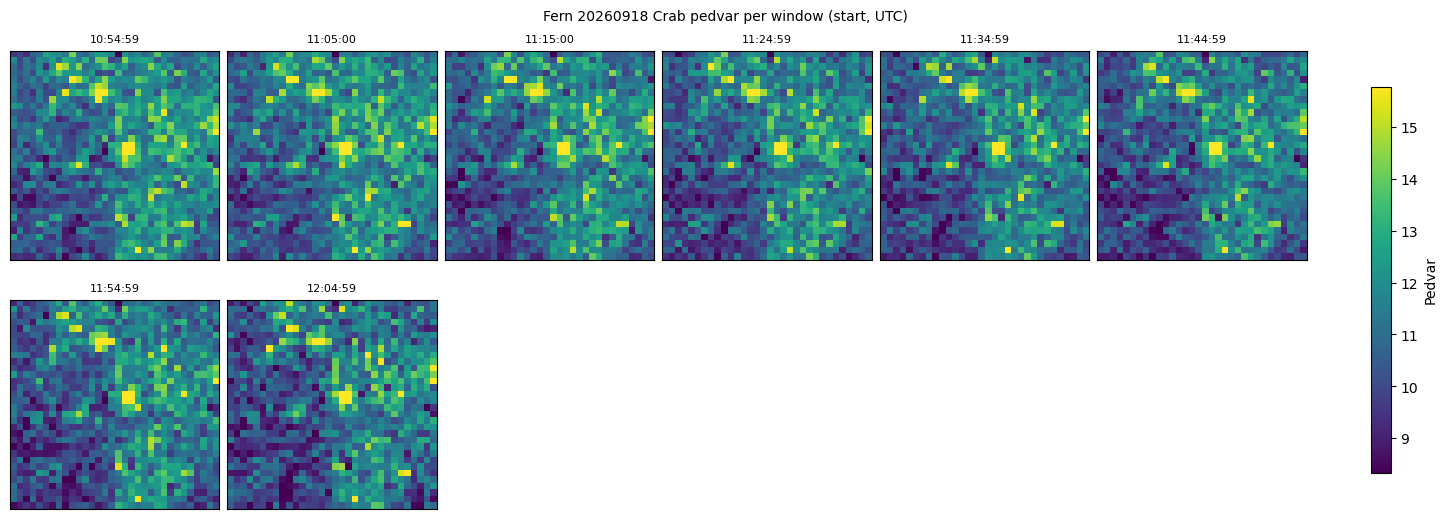

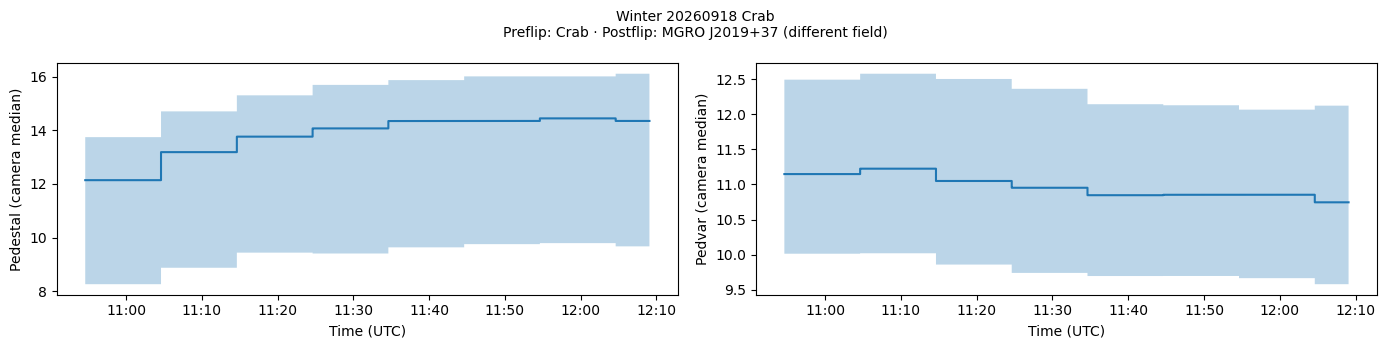

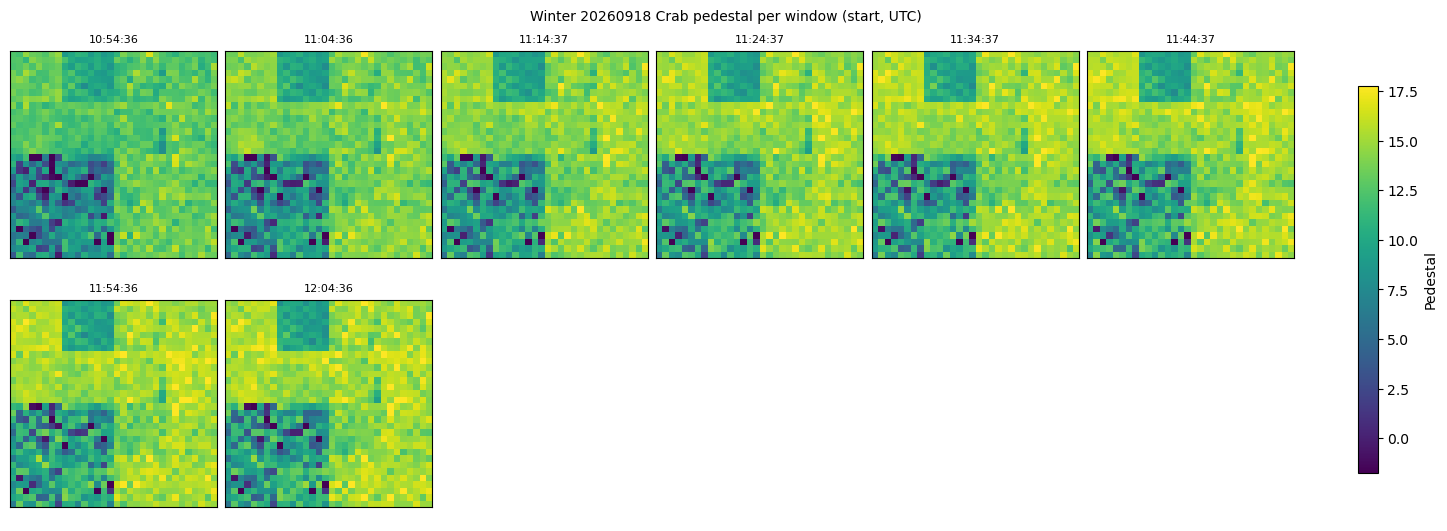

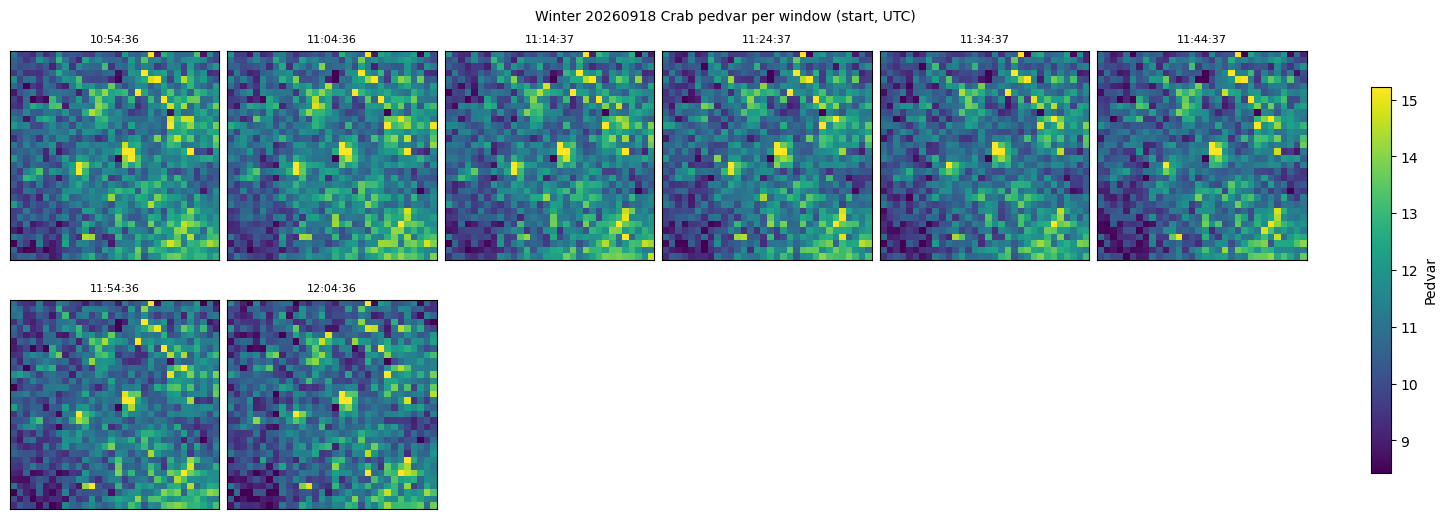

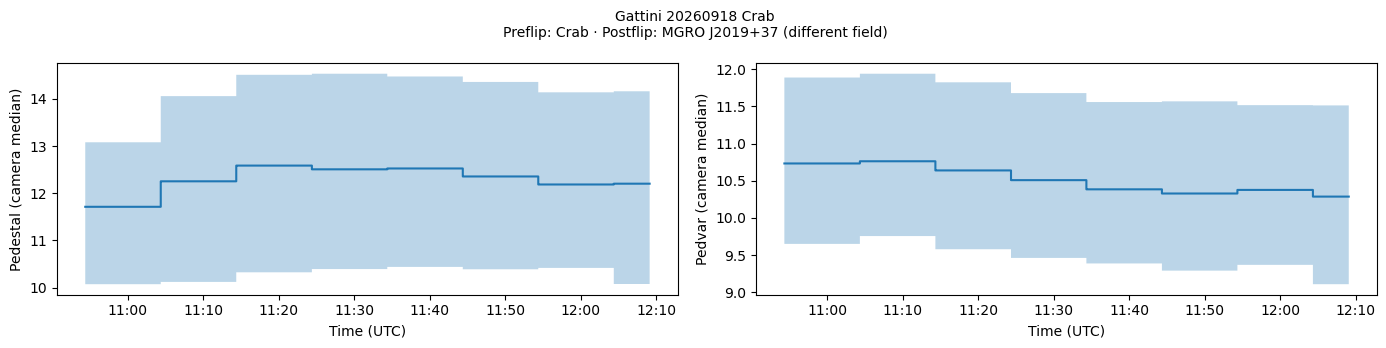

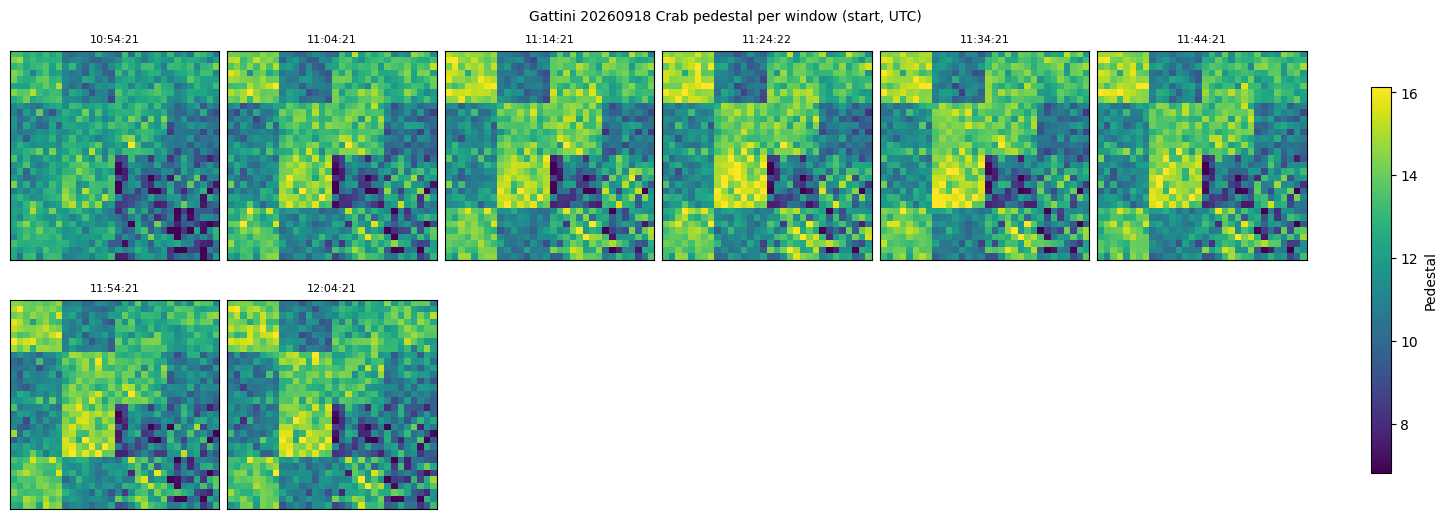

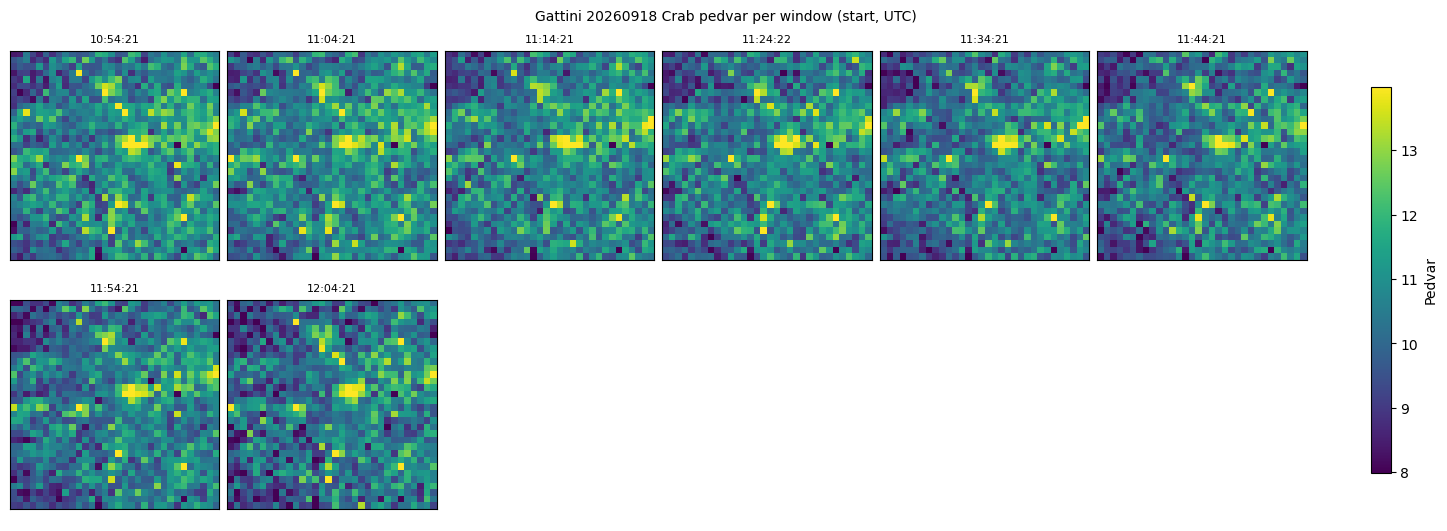

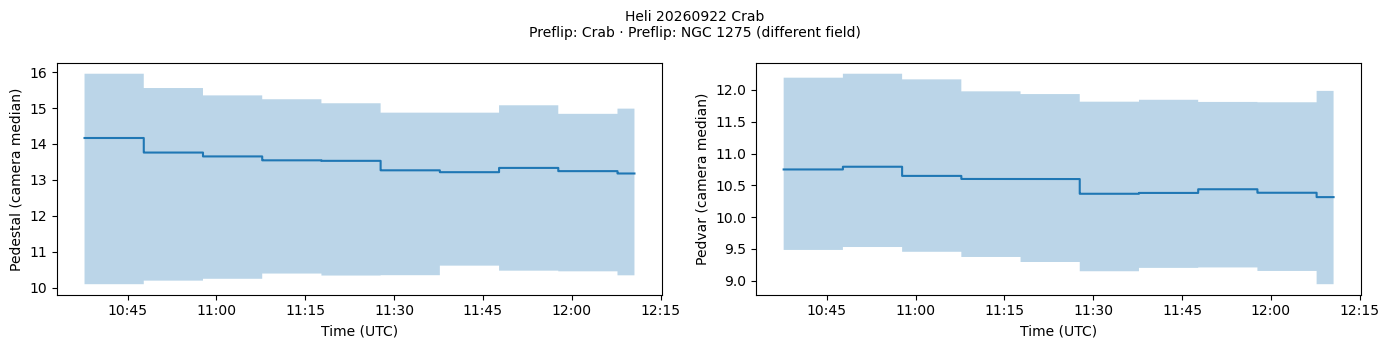

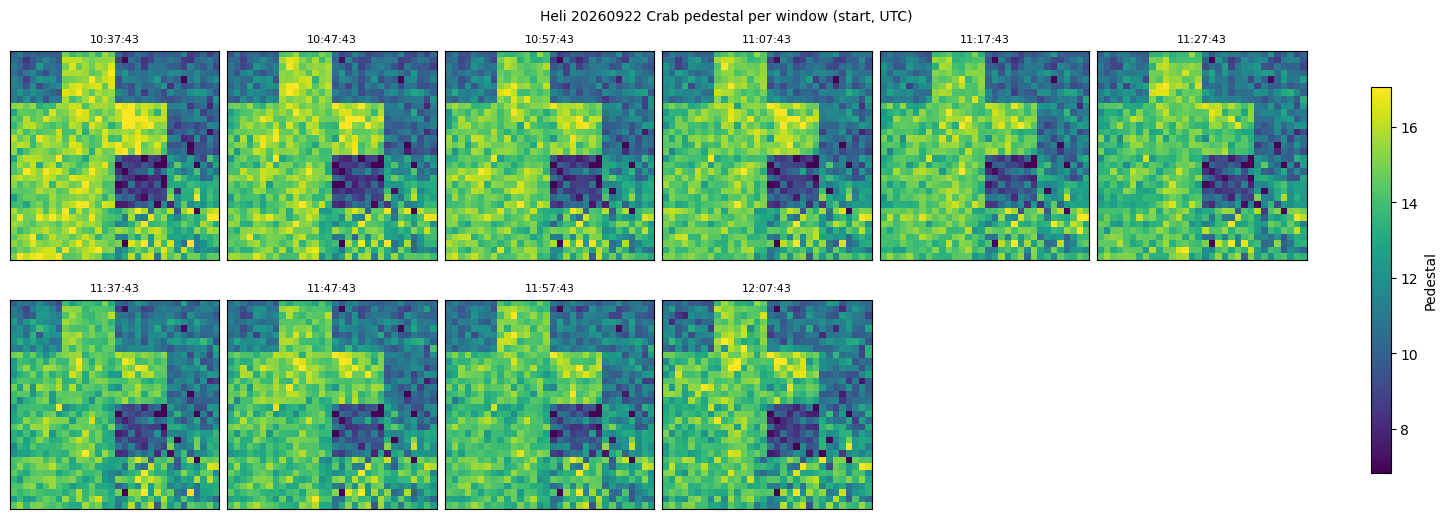

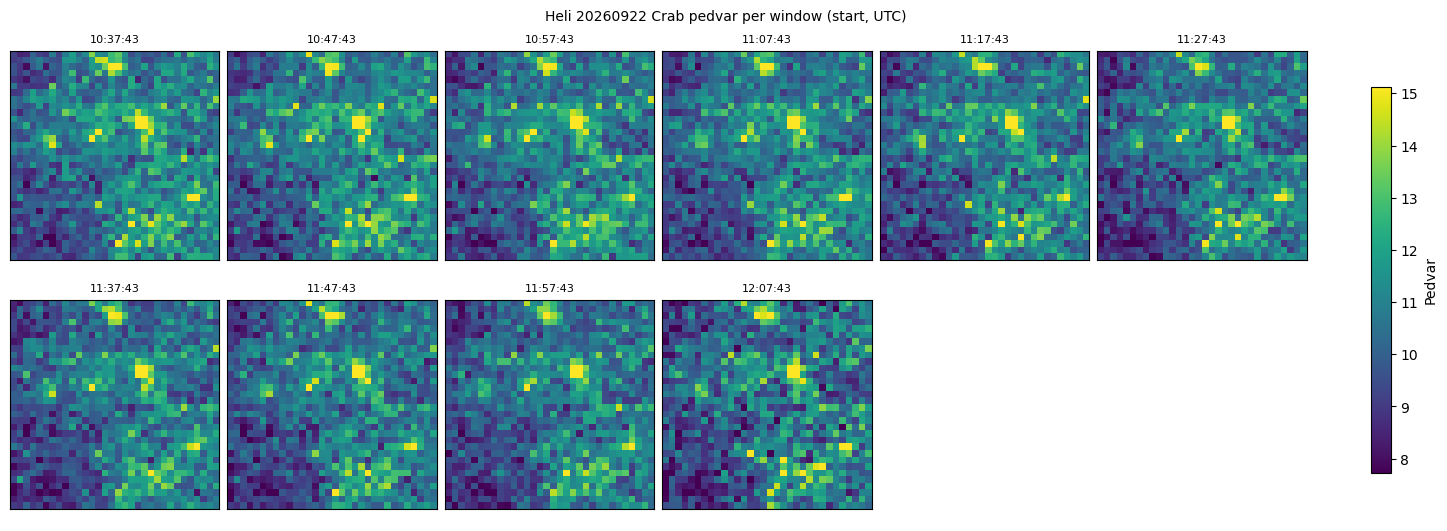

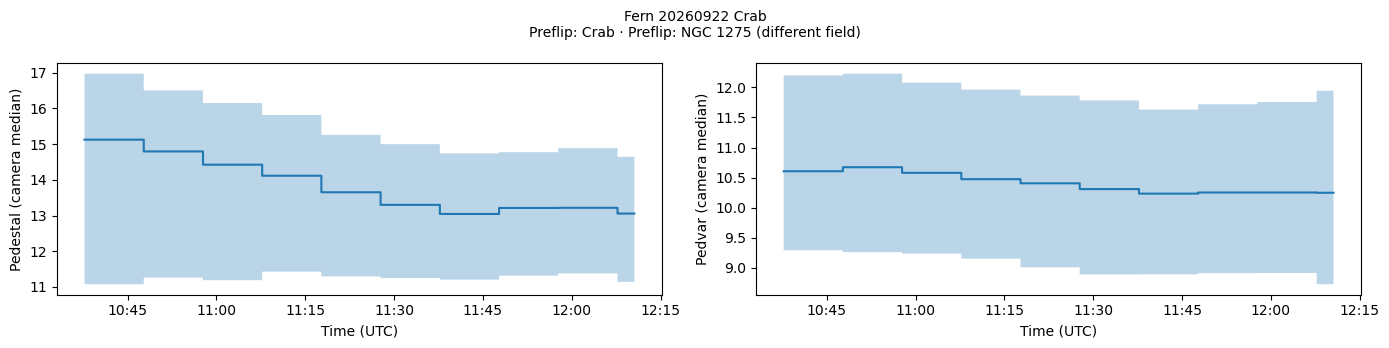

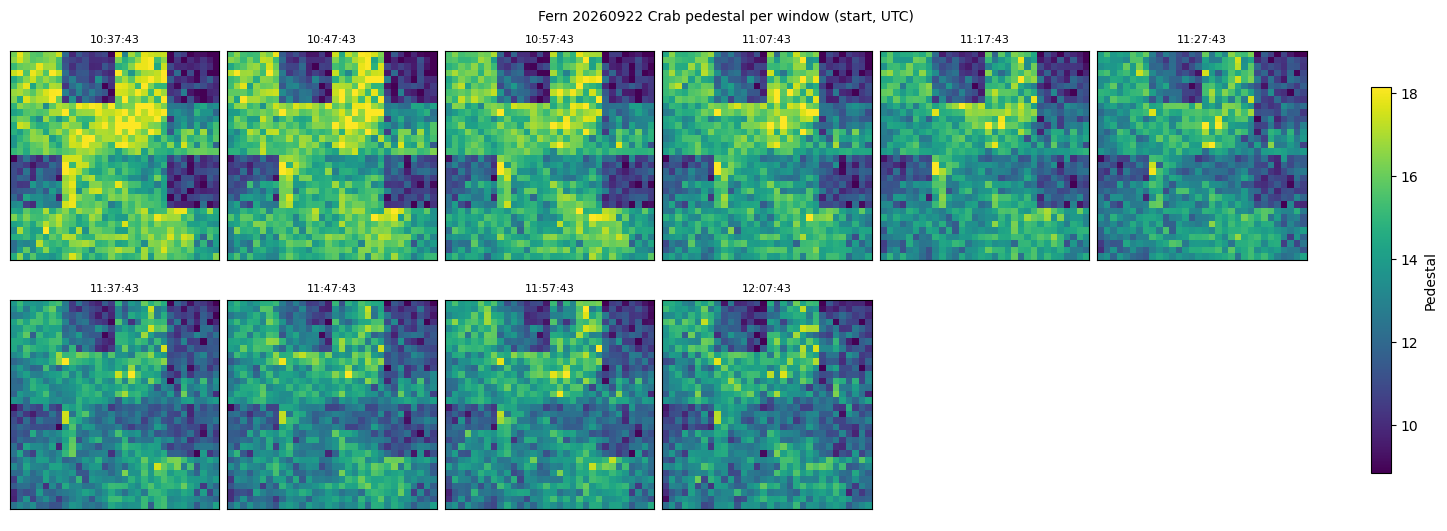

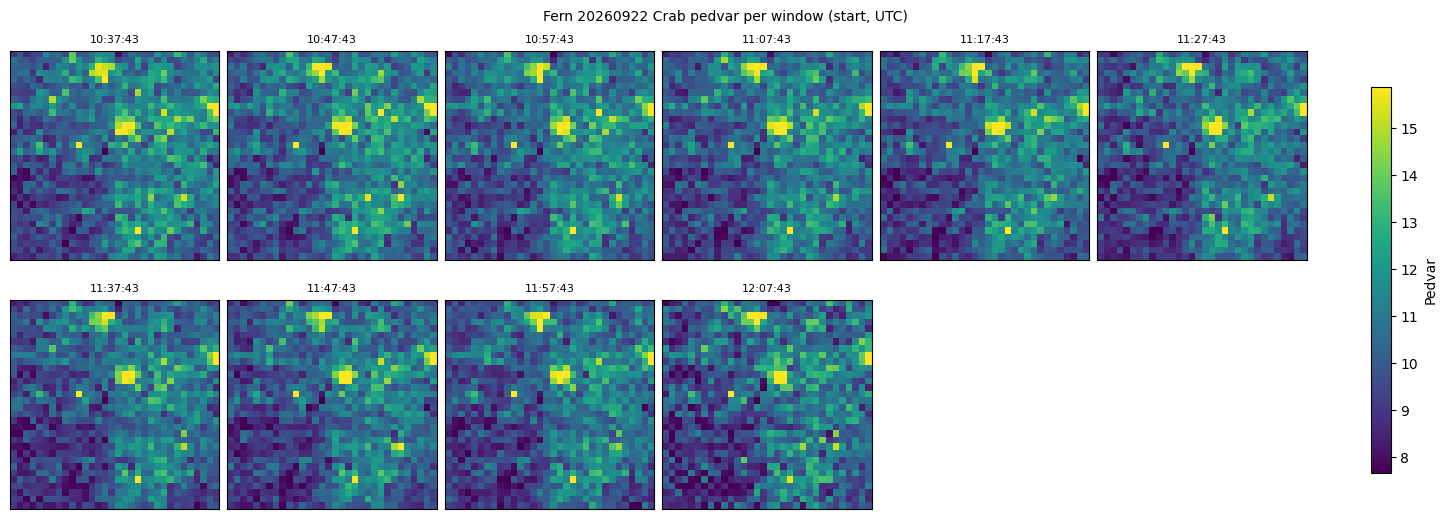

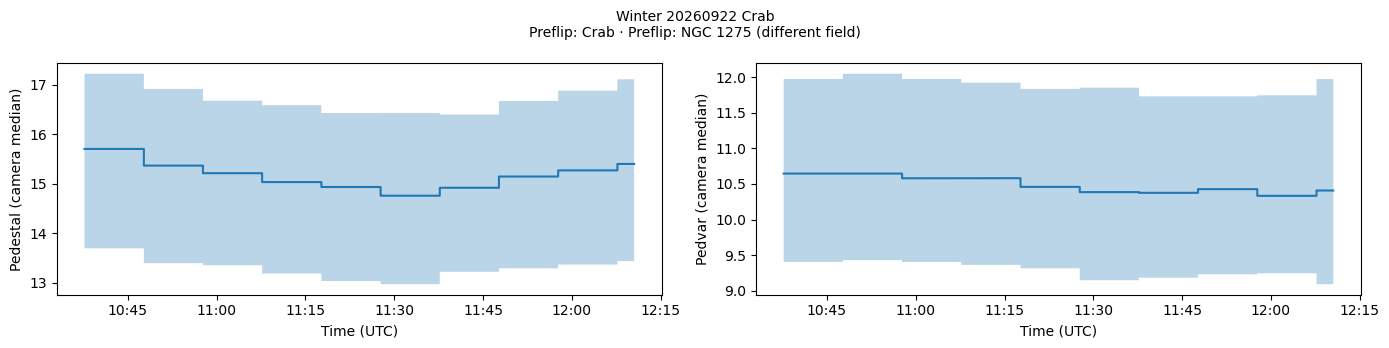

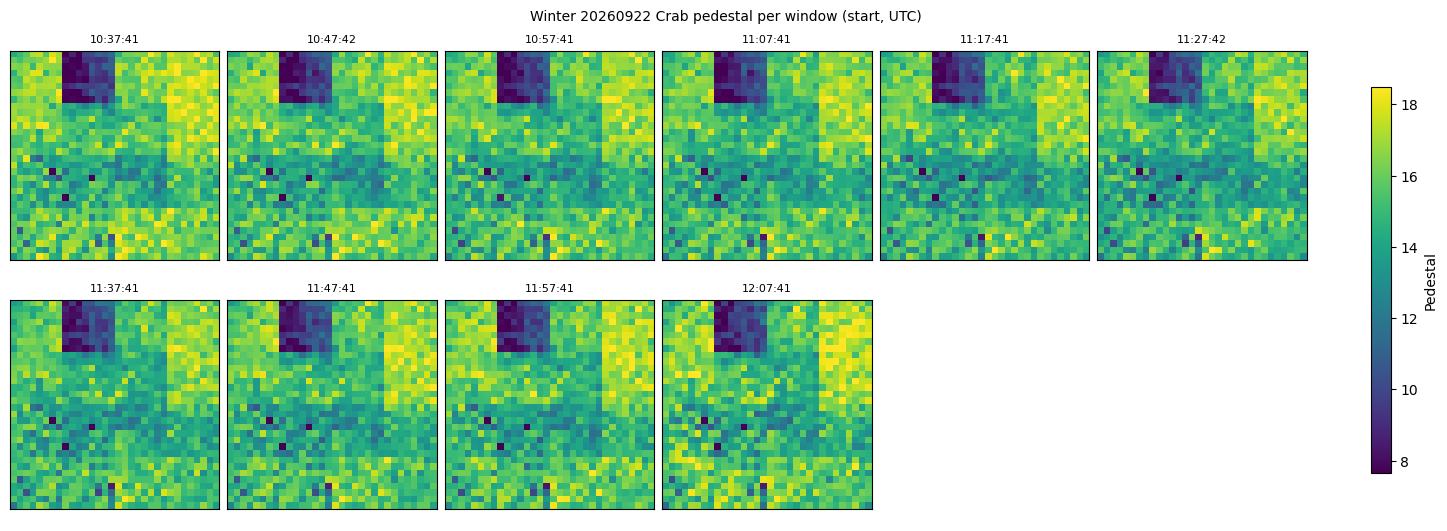

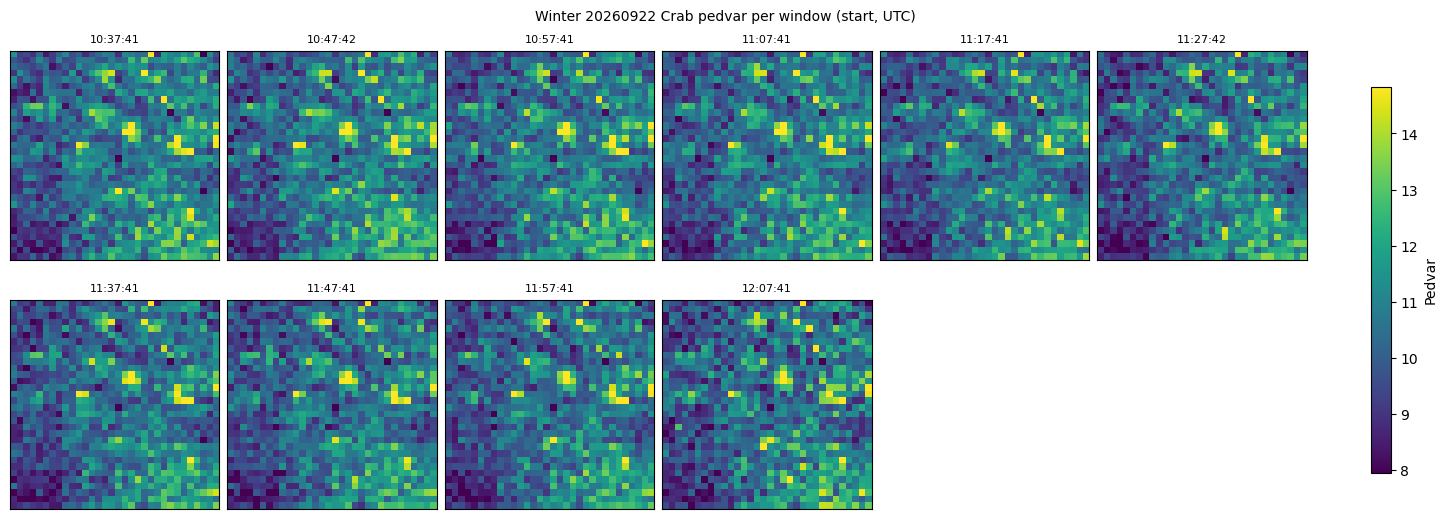

In [11]:
for date in DATES:
    for telescope in TELESCOPES:
        if ev.params_path(OUTPUT_DIR, date, telescope, SOURCE).exists():
            params, _, calib = dg.load_products(OUTPUT_DIR, date, telescope, SOURCE)
            dg.plot_calibrations(params, calib, f"{telescope} {date} {SOURCE}")
            dg.plot_calibration_windows(params, calib, f"{telescope} {date} {SOURCE}")
            plt.show()

## Rates
Frames kept after the cuts, and images with at least `MIN_NPIX` pixels after cleaning.

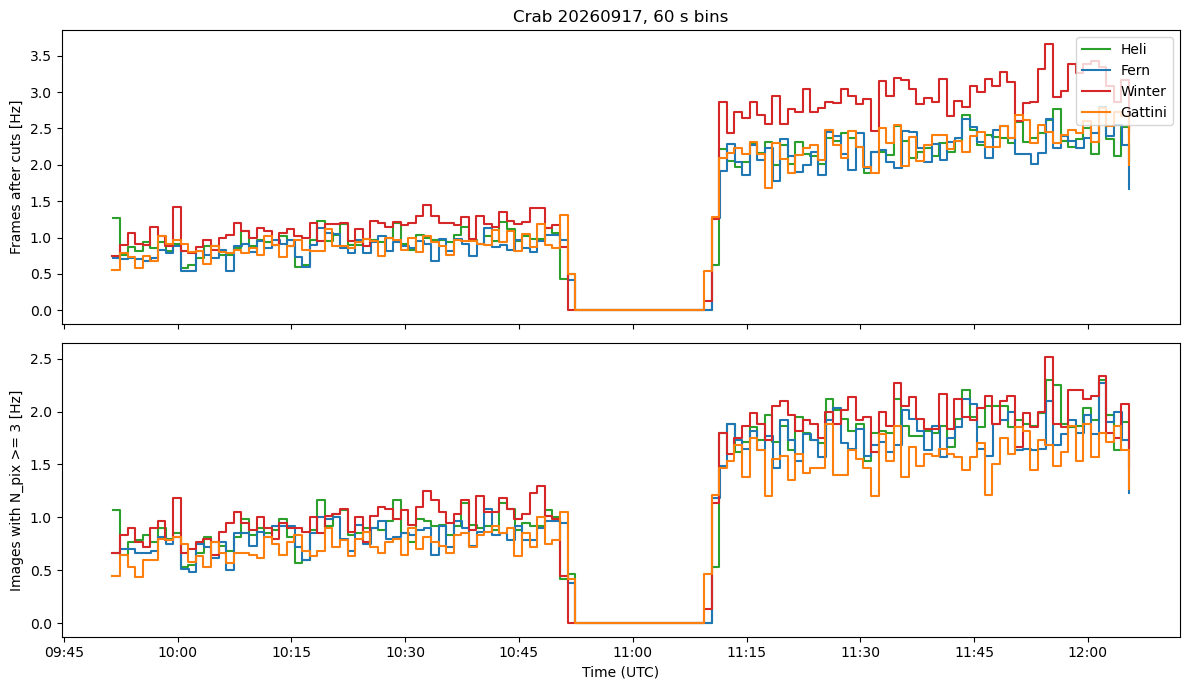

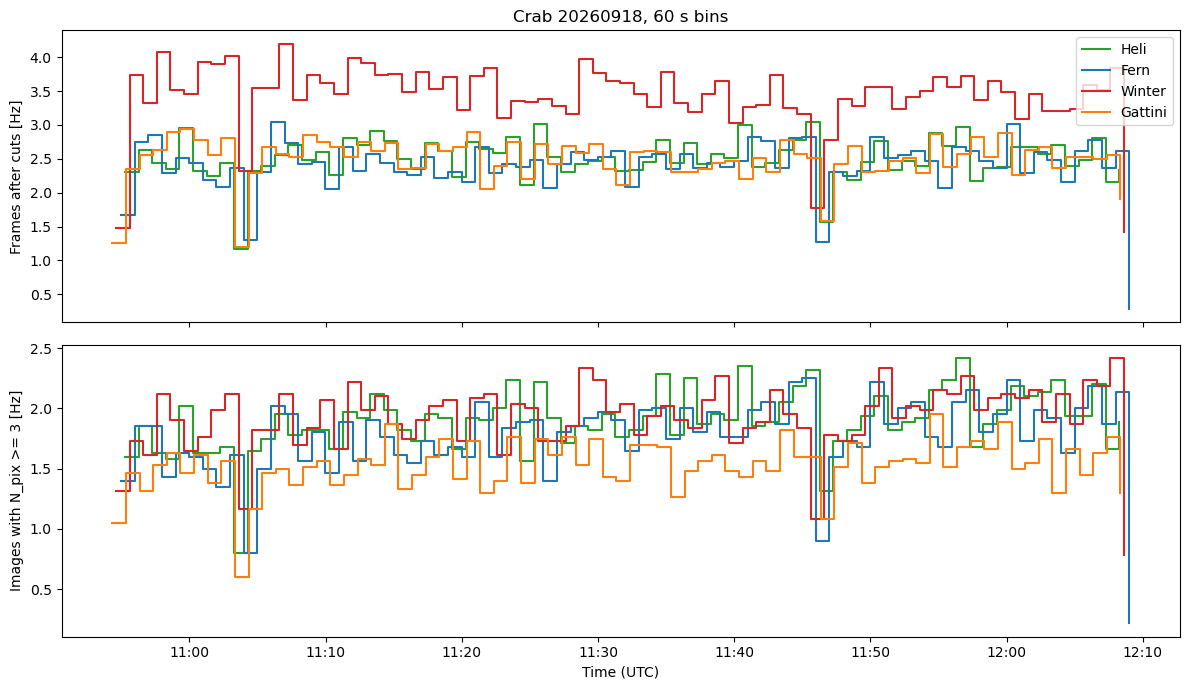

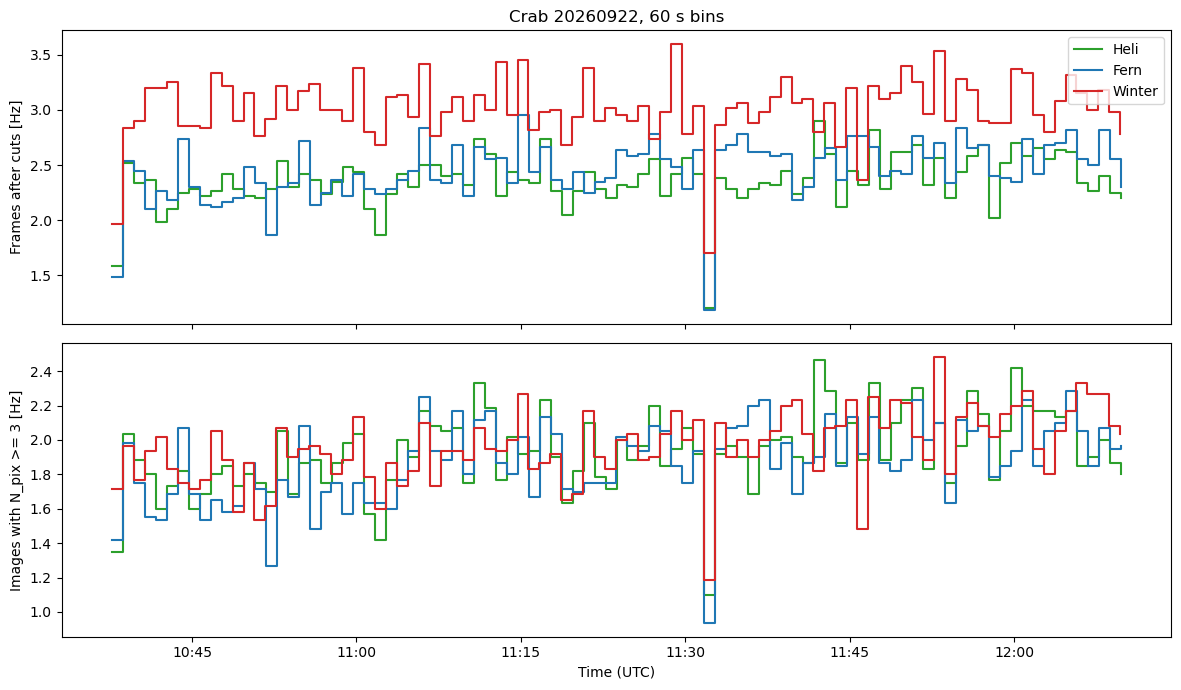

In [12]:
for date in DATES:
    dg.plot_rates(OUTPUT_DIR, date, TELESCOPES, SOURCE, min_npix=MIN_NPIX, colors=COLORS)
    plt.show()